In [1]:
import numpy as np
from utils import *
from models.double_bind_model import DoubleBindModel
from models.single_therapy_model import SingleTherapyModel
from models.combination_model import CombinationModel

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid", {"grid.color": ".6", "grid.linestyle": ":"})

from copy import deepcopy

import warnings
warnings.filterwarnings("ignore")


## Global Parameters

In [2]:
growth_rate_fixed = 0.28

maximum_carrying_capacity = 100
maximum_carrying_capacity_std = 10

strategy_max_efficacy = 0
cost_of_evolvability = 0.12

baseline_heterogeneity = 0.025 ## Same as baseline evolvability for fixed evo models


### Chemo Parameters

efficacy_chemo = 0.17
efficacy_chemo_std = np.sqrt(6)  ## Treatment Generality
evolvability_scaling_factor_chemo = 1.91



### Targeted

efficacy_targeted = 0.31
efficacy_targeted_std = np.sqrt(2)  ## Treatment Generality
evolvability_scaling_factor_targeted = 1.04
### Evolvability

LOW_EVOLVABILITY = 0.2
HIGH_EVOLVABILITY = 0.35

cycle = 50 #cycle duration
cov = 0.015 #covariamce

### Graphing Parameters

targeted_color = "#dc143c"  
chemo_color = "#6A5ACD"
double_bind_color = "#9932CC"



## Adaptive Landscape

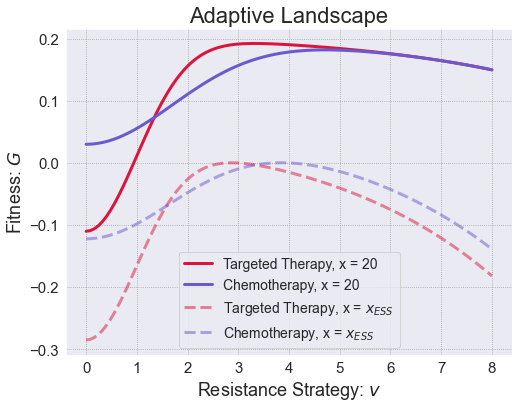

Maximum G_chemo (x=20) = 0.1819 at v = 4.6869
Maximum G_targeted (x=20) = 0.1922 at v = 3.3131
Maximum G_chemo (x=ESS) = 0.0003 at v = 3.8788
Maximum G_targeted (x=ESS) = 0.0002 at v = 2.9091


In [3]:
linewidth = 3
label_font = 20
font_title = 22
font_axis = 18
font_legend = 14
font_ticks = 15

v_vals = np.linspace(0, 8, 100)

G_chemo = G_function(v_vals, 20, growth_rate_fixed, maximum_carrying_capacity, maximum_carrying_capacity_std,
                     efficacy_chemo, strategy_max_efficacy, efficacy_chemo_std,
                     cost_of_evolvability, LOW_EVOLVABILITY)

G_targeted = G_function(v_vals, 20, growth_rate_fixed, maximum_carrying_capacity, maximum_carrying_capacity_std,
                        efficacy_targeted, strategy_max_efficacy, efficacy_targeted_std,
                        cost_of_evolvability, LOW_EVOLVABILITY)

G_chemo_ESS = G_function(v_vals, 74.32, growth_rate_fixed, maximum_carrying_capacity, maximum_carrying_capacity_std,
                     efficacy_chemo, strategy_max_efficacy, efficacy_chemo_std,
                     cost_of_evolvability, LOW_EVOLVABILITY)

G_targeted_ESS = G_function(v_vals, 82.47, growth_rate_fixed, maximum_carrying_capacity, maximum_carrying_capacity_std,
                        efficacy_targeted, strategy_max_efficacy, efficacy_targeted_std,
                        cost_of_evolvability, LOW_EVOLVABILITY)



plt.figure(figsize=(8, 6))
plt.plot(v_vals, G_targeted, label="Targeted Therapy, x = 20", color=targeted_color, linewidth = linewidth)
plt.plot(v_vals, G_chemo, label="Chemotherapy, x = 20", color=chemo_color, linewidth = linewidth)

plt.plot(v_vals, G_targeted_ESS, label="Targeted Therapy, x = $x_{ESS}$", color=targeted_color, linewidth = linewidth, linestyle = '--', alpha = 0.5)
plt.plot(v_vals, G_chemo_ESS, label="Chemotherapy, x = $x_{ESS}$", color=chemo_color, linewidth = linewidth, linestyle = '--', alpha = 0.5)
plt.legend(fontsize = font_legend)

plt.tick_params(labelsize=font_ticks)

plt.title("Adaptive Landscape", fontsize = font_title)
plt.xlabel("Resistance Strategy: $v$", fontsize = font_axis)
plt.ylabel("Fitness: $G$", fontsize = font_axis)
plt.grid(True)
plt.show()



def find_max_info(G_vals, v_vals, label):
    idx = np.argmax(G_vals)
    print(f"Maximum {label} = {G_vals[idx]:.4f} at v = {v_vals[idx]:.4f}")

find_max_info(G_chemo, v_vals, "G_chemo (x=20)")
find_max_info(G_targeted, v_vals, "G_targeted (x=20)")
find_max_info(G_chemo_ESS, v_vals, "G_chemo (x=ESS)")
find_max_info(G_targeted_ESS, v_vals, "G_targeted (x=ESS)")


## Constant Evolvability Panels

In [4]:
## Fixed Evo Models

init = [20, 0.01]

low_evo_constant_model_chemo = SingleTherapyModel(
    init = init,
    #t_max = 5000,

    growth_rate = growth_rate_fixed,
    carrying_capacity_std = maximum_carrying_capacity_std,
    evolvability_cost = cost_of_evolvability,

    
    
    
    efficacy=efficacy_chemo,
    efficacy_std=efficacy_chemo_std,
    evolvability_value = LOW_EVOLVABILITY,

    facultative_evolvability=False,
    intermittent = False
)

#low_evo_constant_model_chemo.get_scaling_factor(HIGH_EVOLVABILITY)
low_evo_constant_model_chemo.run()
low_evo_constant_model_chemo.apply_extinction()

low_evo_constant_model_targeted = SingleTherapyModel(
    init = init,
    #t_max = 5000,

    growth_rate = growth_rate_fixed,
    carrying_capacity_std = maximum_carrying_capacity_std,
    evolvability_cost = cost_of_evolvability,
    
    efficacy=efficacy_targeted,
    efficacy_std=efficacy_targeted_std,
    evolvability_value = LOW_EVOLVABILITY,

    facultative_evolvability=False,
    intermittent = False
)

#low_evo_constant_model_targeted.get_scaling_factor(HIGH_EVOLVABILITY)
low_evo_constant_model_targeted.run()
low_evo_constant_model_targeted.apply_extinction()

high_evo_constant_model_chemo = SingleTherapyModel(
    init = init,
    #t_max = 5000,

    growth_rate = growth_rate_fixed,
    carrying_capacity_std = maximum_carrying_capacity_std,
    evolvability_cost = cost_of_evolvability,

    efficacy=efficacy_chemo,
    efficacy_std=efficacy_chemo_std,
    evolvability_value = HIGH_EVOLVABILITY,

    facultative_evolvability=False,
    intermittent = False
)

#high_evo_constant_model_chemo.get_scaling_factor(HIGH_EVOLVABILITY)
high_evo_constant_model_chemo.run()
high_evo_constant_model_chemo.apply_extinction()

high_evo_constant_model_targeted = SingleTherapyModel(
    init = init,

    growth_rate = growth_rate_fixed,
    carrying_capacity_std = maximum_carrying_capacity_std,
    evolvability_cost = cost_of_evolvability,

    
    efficacy=efficacy_targeted,
    efficacy_std=efficacy_targeted_std,
    evolvability_value = HIGH_EVOLVABILITY,

    facultative_evolvability=False,
    intermittent = False
)

for model in [high_evo_constant_model_chemo, high_evo_constant_model_targeted, low_evo_constant_model_chemo, low_evo_constant_model_targeted]:

    model.run()
    model.apply_extinction()

    

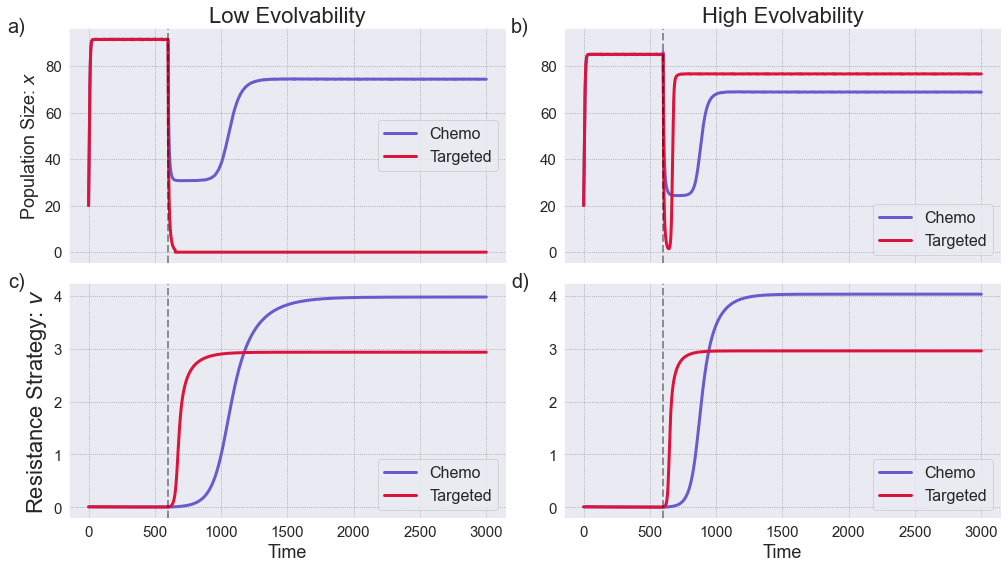

In [5]:
## Make plots

linewidth = 3
label_font = 20
font_title = 22
font_axis = 18
font_legend = 16
font_ticks = 15

panel_labels = ['a)', 'b)', 'c)', 'd)']
label_positions = [(-0.1, 1.05), (-0.08, 1.05),  # top row
                   (-0.1, 1.05), (-0.08, 1.05)]  # bottom row

fig, ax = plt.subplots(2, 2, figsize=(14, 8), sharex=True)



# === Top Left: Low Evolvability - Population ===
ax[0, 0].set_title("Low Evolvability", fontsize = font_title)
#ax[0, 0].set_ylim(0, 100)
ax[0, 0].plot(low_evo_constant_model_chemo.t, low_evo_constant_model_chemo.y[0], color=chemo_color, linewidth=linewidth, label="Chemo")
ax[0, 0].plot(low_evo_constant_model_targeted.t, low_evo_constant_model_targeted.y[0], color=targeted_color, linewidth=linewidth, label="Targeted")
ax[0, 0].set_ylabel("Population Size: $x$", fontsize = font_axis)

# === Bottom Left: Low Evolvability - Strategy ===
#ax[1, 1].set_title("Low Evolvability - Strategy")
ax[1, 0].set_xlabel("Time", fontsize = font_axis)
ax[1, 0].plot(low_evo_constant_model_chemo.t, low_evo_constant_model_chemo.y[1], color=chemo_color, linewidth=linewidth, label="Chemo")
ax[1, 0].plot(low_evo_constant_model_targeted.t, low_evo_constant_model_targeted.y[1], color=targeted_color, linewidth=linewidth, label="Targeted")
ax[1, 0].set_ylabel("Resistance Strategy: $v$", fontsize = font_title)

# === Top Right: High Evolvability - Population ===
ax[0, 1].set_title("High Evolvability", fontsize = font_title)

#ax[0, 1].set_ylim(0, 100)
ax[0, 1].plot(high_evo_constant_model_chemo.t, high_evo_constant_model_chemo.y[0], color=chemo_color, linewidth=linewidth, label="Chemo")
ax[0, 1].plot(high_evo_constant_model_targeted.t, high_evo_constant_model_targeted.y[0], color=targeted_color, linewidth=linewidth, label="Targeted")

# === Bottom Right: High Evolvability - Strategy ===
#ax[1, 0].set_title("High Evolvability - Strategy")

ax[1, 1].set_xlabel("Time", fontsize = font_axis)
ax[1, 1].plot(high_evo_constant_model_chemo.t, high_evo_constant_model_chemo.y[1], color=chemo_color, linewidth=linewidth, label="Chemo")
ax[1, 1].plot(high_evo_constant_model_targeted.t, high_evo_constant_model_targeted.y[1], color=targeted_color, linewidth=linewidth, label="Targeted")

# === Final polish ===
for i, axes in enumerate(ax.flat):
    axes.axvline(x=high_evo_constant_model_chemo.therapy_start_time, color='black',
                 linestyle='--', linewidth=2, alpha=0.4)
    axes.tick_params(labelsize=font_ticks)
    axes.legend(fontsize=font_legend)

    x_pos, y_pos = label_positions[i]
    axes.text(x_pos, y_pos, panel_labels[i], transform=axes.transAxes,
              fontsize=label_font, va='top', ha='right')
    
    
#repeat_legend(ax)
match_ylim_by_row(ax)


plt.tight_layout()
plt.show()


# print(high_evo_constant_model_chemo.y[0][500], low_evo_constant_model_chemo.y[0][500])
# print(high_evo_constant_model_chemo.y[0][-1], low_evo_constant_model_chemo.y[0][-1])
# print(high_evo_constant_model_targeted.y[0][-1], low_evo_constant_model_targeted.y[0][-1])



## Facultative Panels

In [6]:
facultative_model_chemo = SingleTherapyModel(
    init = init,

    growth_rate = growth_rate_fixed,
    carrying_capacity_std = maximum_carrying_capacity_std,
    evolvability_cost = cost_of_evolvability,

    efficacy=efficacy_chemo,
    efficacy_std=efficacy_chemo_std,
    evolvability_value = baseline_heterogeneity,

    facultative_evolvability=True,
    intermittent = False
)




facultative_model_targeted = SingleTherapyModel(
    init = init,

    growth_rate = growth_rate_fixed,
    carrying_capacity_std = maximum_carrying_capacity_std,
    evolvability_cost = cost_of_evolvability,

    efficacy=efficacy_targeted,
    efficacy_std=efficacy_targeted_std,
    evolvability_value = baseline_heterogeneity,

    facultative_evolvability=True,
    intermittent = False
)


for model in [facultative_model_chemo, facultative_model_targeted]:
    model.get_evolvability_scaling_factor(HIGH_EVOLVABILITY)
    print(model.evolvability_scaling_factor)
    model.run()
    model.apply_extinction()



1.9117647058823526
1.0483870967741935


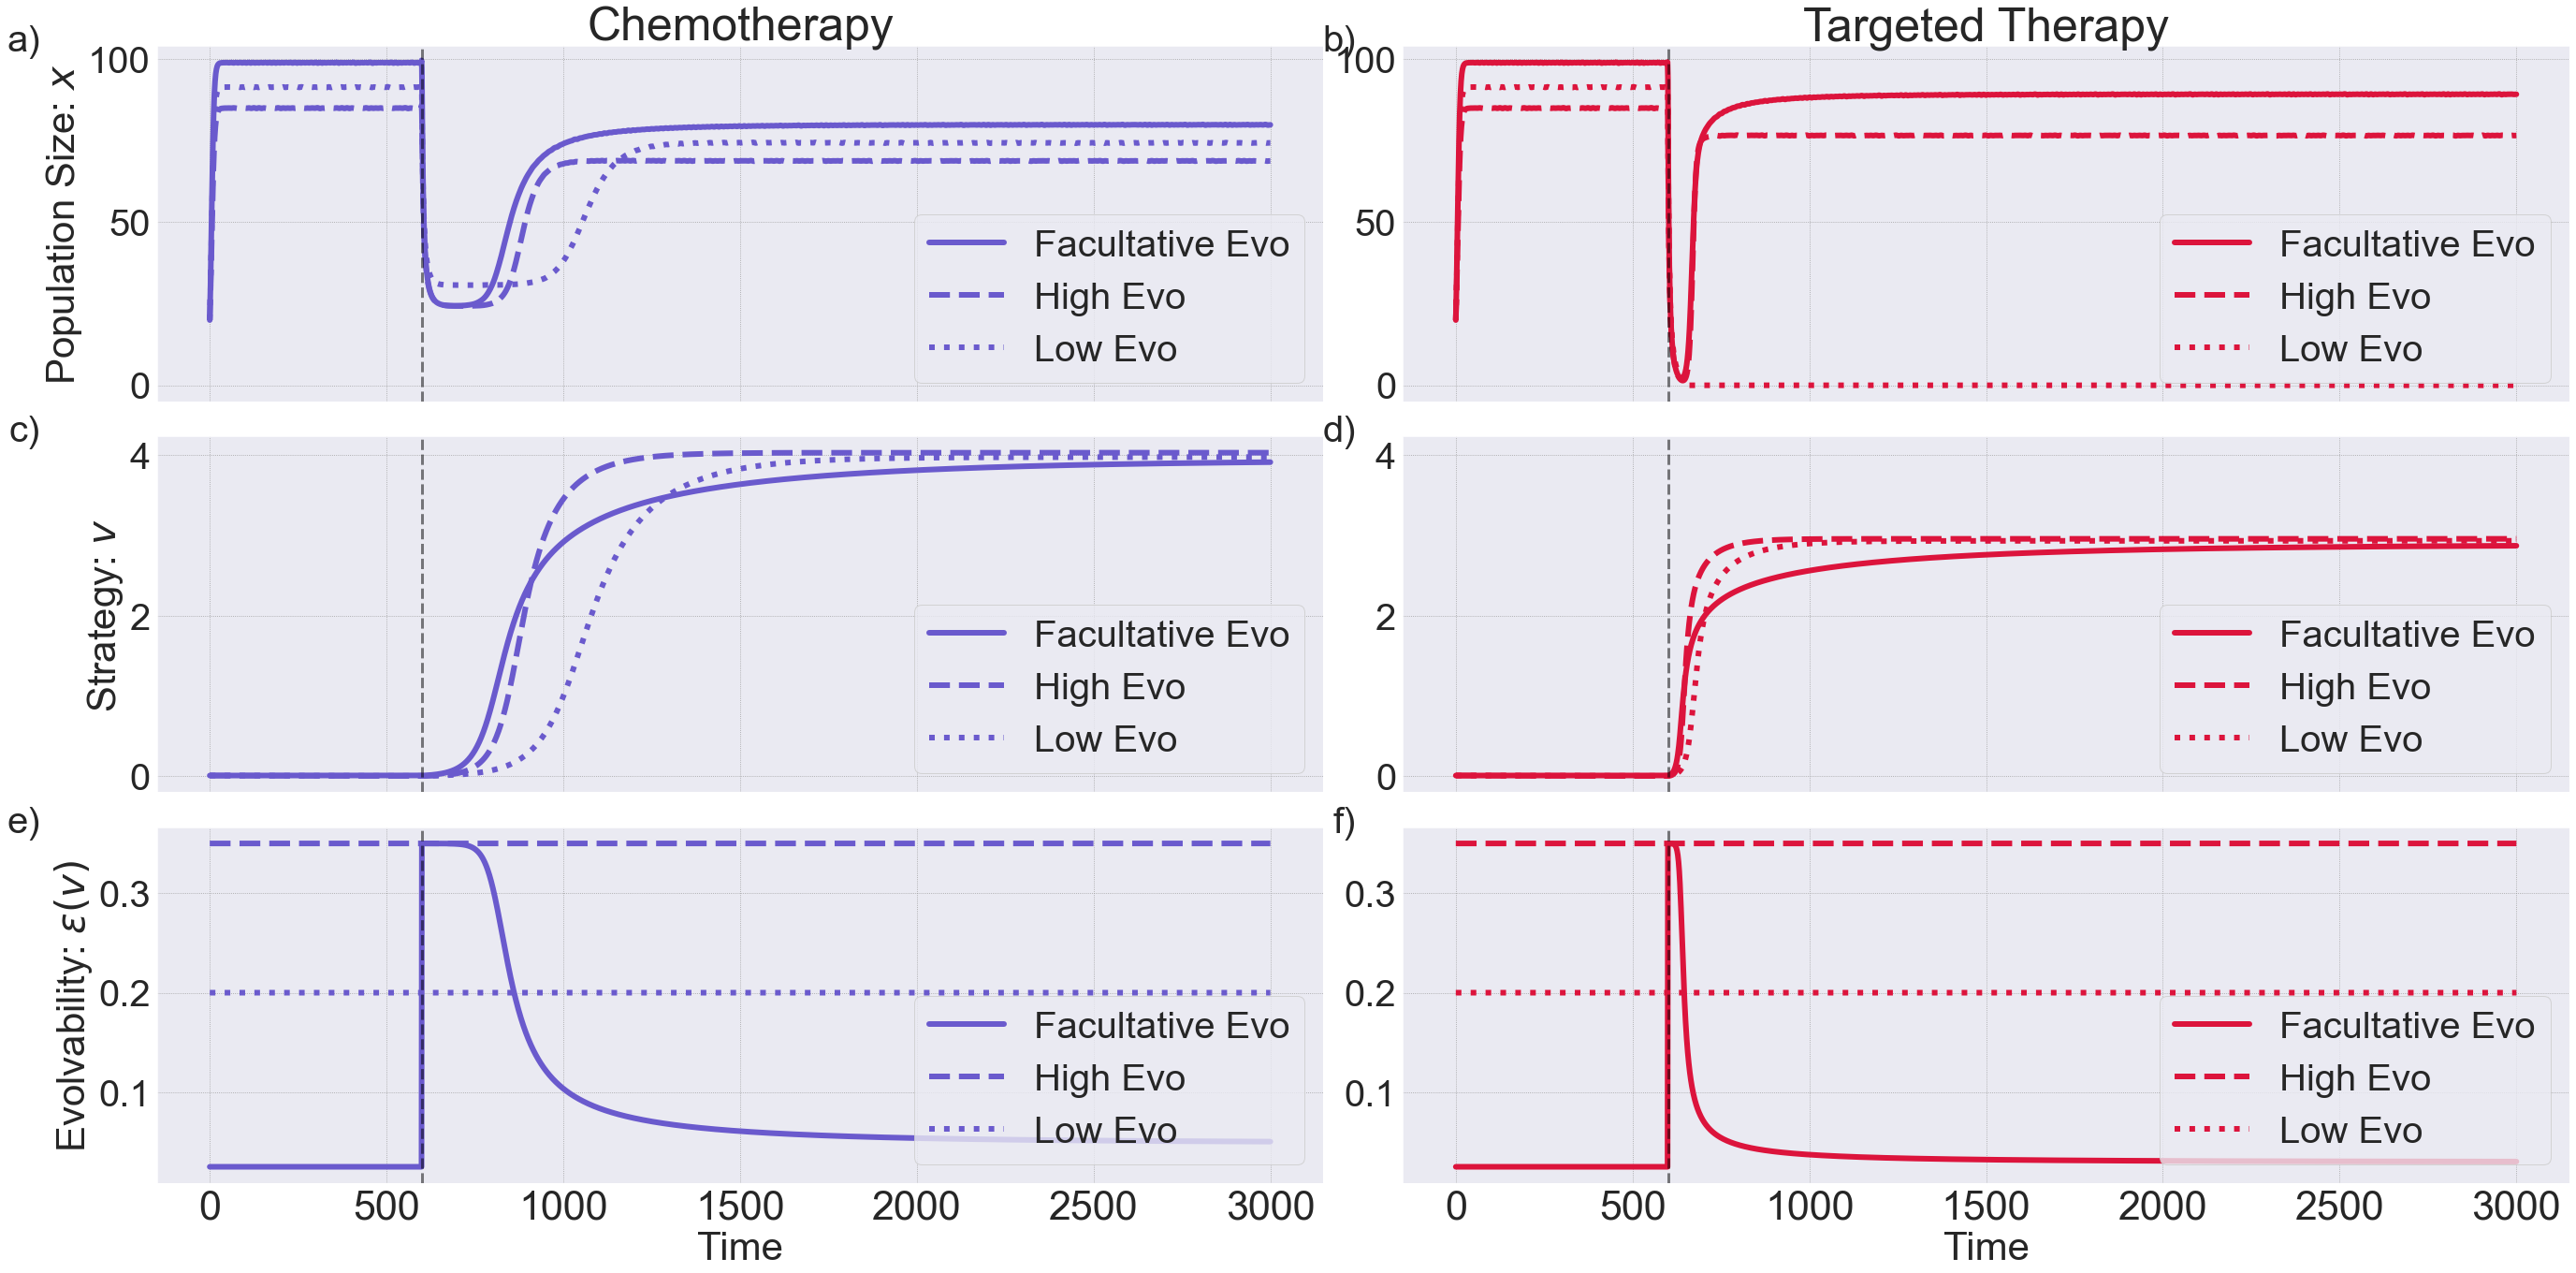

98.9893076318575 98.9893076318575
79.86904883130715 89.23045836660407


In [7]:
linewidth = 6
label_font = 40        # font for subplot labels (a), (b), etc.
font_title = 50        # font for subplot titles
font_axis = 42         # font for axis labels
font_legend = 40       # font for legend
font_ticks_y = 40      # font for y-axis tick labels
font_ticks_x = 43      # font for x-axis tick labels


panel_labels = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)']
label_positions = [(-0.10, 1.06),  # (a) top-left
                   (-0.04, 1.06),  # (b) top-right
                   (-0.10, 1.06),  # (c) mid-left
                   (-0.04, 1.06),  # (d) mid-right
                   (-0.10, 1.06),  # (e) bottom-left
                   (-0.04, 1.06)]  # (f) bottom-right

fig, ax = plt.subplots(3, 2, figsize=(38, 19), sharex=True)

# === Top Left: Facultative Evolvability - Population (Chemo) ===
ax[0, 0].set_title("Chemotherapy", fontsize = font_title) 
ax[0, 0].plot(facultative_model_chemo.t, facultative_model_chemo.y[0], color=chemo_color, linewidth=linewidth, label="Facultative Evo")
ax[0, 0].plot(high_evo_constant_model_chemo.t, high_evo_constant_model_chemo.y[0], color=chemo_color, linestyle='--', linewidth=linewidth, label="High Evo")
ax[0, 0].plot(low_evo_constant_model_chemo.t, low_evo_constant_model_chemo.y[0], color=chemo_color, linestyle=':', linewidth=linewidth, label="Low Evo")
ax[0, 0].set_ylabel("Population Size: $x$", fontsize = font_axis)
ax[0, 0].legend()

# === Middle Left: Facultative Evolvability - Strategy (Chemo)===
#ax[1, 0].set_title("Chemotherapy - Strategy")
ax[1, 0].plot(facultative_model_chemo.t, facultative_model_chemo.y[1], color=chemo_color, linewidth=linewidth, label="Facultative Evo")
ax[1, 0].plot(high_evo_constant_model_chemo.t, high_evo_constant_model_chemo.y[1], color=chemo_color, linestyle='--', linewidth=linewidth, label="High Evo")  
ax[1, 0].plot(low_evo_constant_model_chemo.t, low_evo_constant_model_chemo.y[1], color=chemo_color, linestyle=':', linewidth=linewidth, label="Low Evo")
ax[1, 0].set_ylabel("Strategy: $v$", fontsize = font_axis)
ax[1, 0].legend()


# === Bottom Left: Evolvability ===
#ax[2, 0].set_title("Chemotherapy - Evolvability")
ax[2, 0].plot(facultative_model_chemo.t, facultative_model_chemo.evo, color=chemo_color, linewidth=linewidth, label="Facultative Evo")
ax[2, 0].plot(high_evo_constant_model_chemo.t, high_evo_constant_model_chemo.evo, color=chemo_color, linestyle='--', linewidth=linewidth, label="High Evo")
ax[2, 0].plot(low_evo_constant_model_chemo.t, low_evo_constant_model_chemo.evo, color=chemo_color, linestyle=':', linewidth=linewidth, label="Low Evo")
ax[2, 0].set_ylabel("Evolvability: $\epsilon(v)$", fontsize = font_axis)
ax[2, 0].set_xlabel("Time", fontsize = font_axis)
ax[2, 0].legend()

# === Top Right: Facultative Evolvability - Population (Targeted) ===
ax[0, 1].set_title("Targeted Therapy", fontsize = font_title)
ax[0, 1].plot(facultative_model_targeted.t, facultative_model_targeted.y[0], color=targeted_color, linewidth=linewidth, label="Facultative Evo")
ax[0, 1].plot(high_evo_constant_model_targeted.t, high_evo_constant_model_targeted.y[0], color=targeted_color, linestyle='--', linewidth=linewidth, label="High Evo")
ax[0, 1].plot(low_evo_constant_model_targeted.t, low_evo_constant_model_targeted.y[0], color=targeted_color, linestyle=':', linewidth=linewidth, label="Low Evo")
#ax[0, 1].set_ylabel("Population Size: $x$", fontsize = font_axis)
ax[0, 1].legend()

# === Middle Right: Facultative Evolvability - Strategy (Targeted) ===
#ax[1, 1].set_title("Targeted Therapy - Strategy")
ax[1, 1].plot(facultative_model_targeted.t, facultative_model_targeted.y[1], color=targeted_color, linewidth=linewidth, label="Facultative Evo")
ax[1, 1].plot(high_evo_constant_model_targeted.t, high_evo_constant_model_targeted.y[1], color=targeted_color, linestyle='--', linewidth=linewidth, label="High Evo")
ax[1, 1].plot(low_evo_constant_model_targeted.t, low_evo_constant_model_targeted.y[1], color=targeted_color, linestyle=':', linewidth=linewidth, label="Low Evo")
#ax[1, 1].set_ylabel("Strategy: $v$", fontsize = font_axis)
ax[1, 1].legend()

# === Bottom Right: Evolvability (Targeted) ===
#ax[2, 1].set_title("Targeted Therapy - Evolvability")
ax[2, 1].plot(facultative_model_targeted.t, facultative_model_targeted.evo, color=targeted_color, linewidth=linewidth, label="Facultative Evo")
ax[2, 1].plot(high_evo_constant_model_targeted.t, high_evo_constant_model_targeted.evo, color=targeted_color, linestyle='--', linewidth=linewidth, label="High Evo")
ax[2, 1].plot(low_evo_constant_model_targeted.t, low_evo_constant_model_targeted.evo, color=targeted_color, linestyle=':', linewidth=linewidth, label="Low Evo")
ax[2, 1].set_xlabel("Time", fontsize = font_axis)
#ax[2, 1].set_ylabel("Evolvability: $\epsilon(v)$", fontsize = font_axis)


for i, axes in enumerate(ax.flat):
    axes.axvline(x=high_evo_constant_model_chemo.therapy_start_time, color='black',
                 linestyle='--', linewidth=3, alpha=0.5)
    axes.tick_params(axis='x', labelsize=font_ticks_x)
    axes.tick_params(axis='y', labelsize=font_ticks_y)

    axes.legend(fontsize=font_legend, loc = "lower right")

    x_pos, y_pos = label_positions[i]
    axes.text(x_pos, y_pos, panel_labels[i], transform=axes.transAxes,
              fontsize=label_font, va='top', ha='right')

#repeat_legend(ax)
match_ylim_by_row(ax)

plt.tight_layout()
plt.show()

print(facultative_model_chemo.y[0][500], facultative_model_targeted.y[0][500])
print(facultative_model_chemo.y[0][-1], facultative_model_targeted.y[0][-1])


## Intermittent Therapy

In [8]:
t_max = 5000
init = [20, 0.01]

# Facultative model
facultative_intermittent_chemo = SingleTherapyModel(
    init=init,
    t_max=t_max,
    growth_rate=growth_rate_fixed,
    carrying_capacity_std = maximum_carrying_capacity_std,
    evolvability_cost = cost_of_evolvability,

    
    efficacy=efficacy_chemo,
    efficacy_std=efficacy_chemo_std,
    evolvability_value=baseline_heterogeneity,
    evolvability_scaling_factor=evolvability_scaling_factor_chemo,
    facultative_evolvability=True,
    intermittent=True,
    cycle_duration = cycle
)


# Low constant evolvability model
low_evo_intermittent_chemo = SingleTherapyModel(
    init=init,
    t_max=t_max,
    growth_rate=growth_rate_fixed,
    carrying_capacity_std = maximum_carrying_capacity_std,
    evolvability_cost = cost_of_evolvability,

    
    efficacy=efficacy_chemo,
    efficacy_std=efficacy_chemo_std,
    evolvability_value=LOW_EVOLVABILITY,
    facultative_evolvability=False,
    intermittent=True,
    cycle_duration = cycle
)


# High constant evolvability model
high_evo_intermittent_chemo = SingleTherapyModel(
    init=init,
    t_max=t_max,
    growth_rate=growth_rate_fixed,
    carrying_capacity_std = maximum_carrying_capacity_std,
    evolvability_cost = cost_of_evolvability,

    
    efficacy=efficacy_chemo,
    efficacy_std=efficacy_chemo_std,
    evolvability_value=HIGH_EVOLVABILITY,
    facultative_evolvability=False,
    intermittent=True,
    cycle_duration = cycle
)

for model in [high_evo_intermittent_chemo, low_evo_intermittent_chemo, facultative_intermittent_chemo]:
    model.get_evolvability_scaling_factor(HIGH_EVOLVABILITY)
    model.run()
    model.apply_extinction()


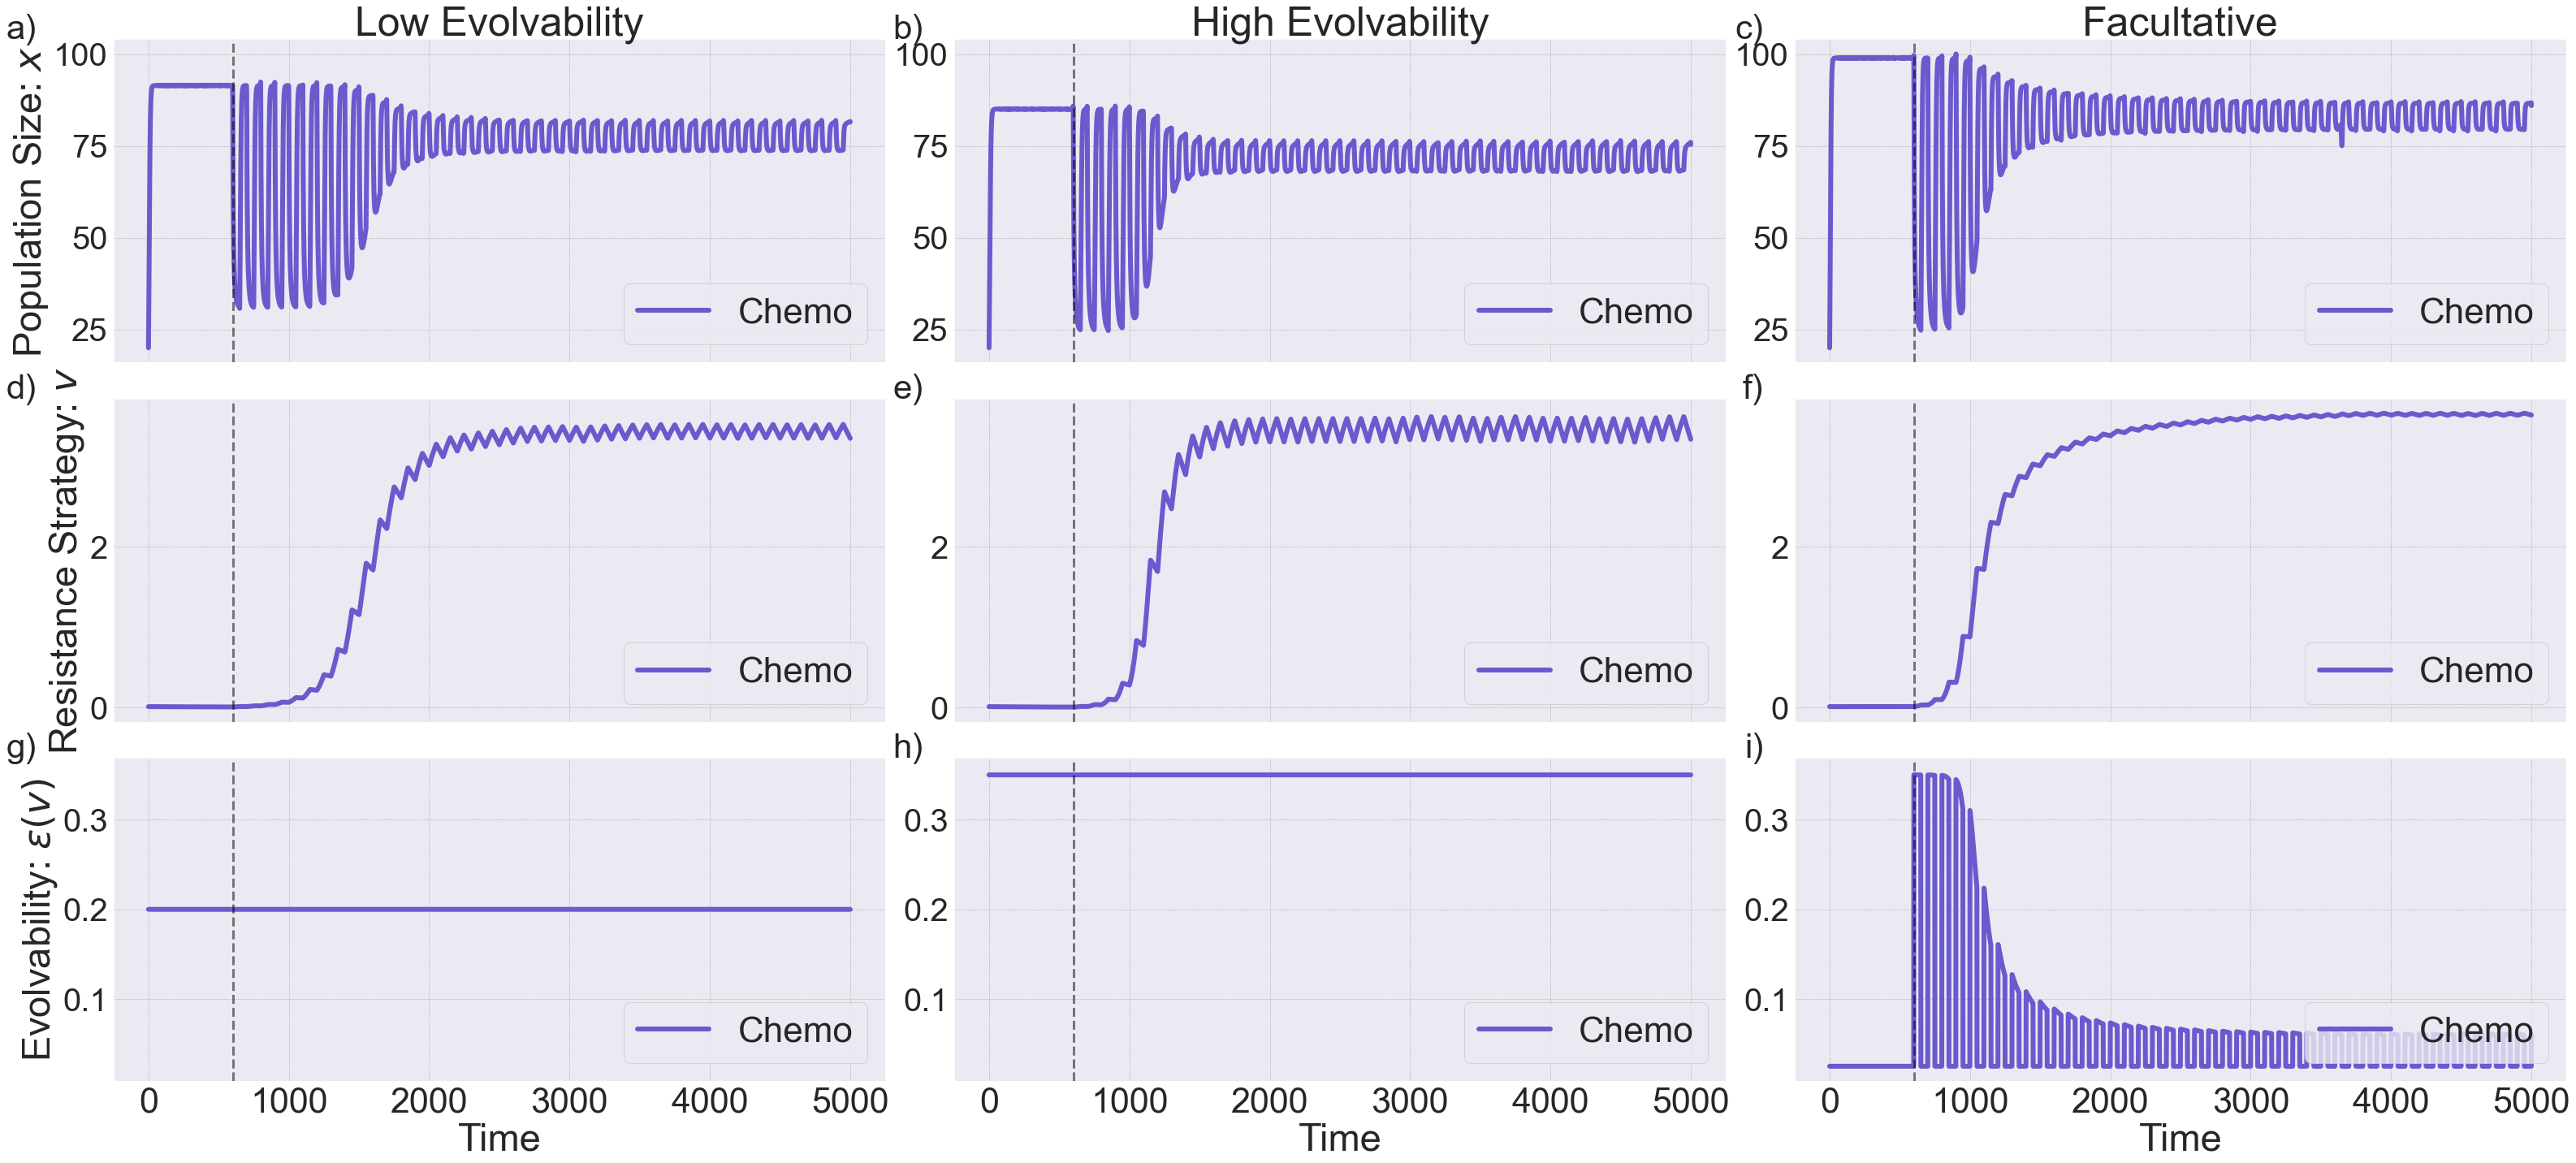

In [9]:
linewidth = 6
label_font = 42        # font for subplot labels (a), (b), etc.
font_title = 50        # font for subplot titles
font_axis = 47        # font for axis labels
font_legend = 44       # font for legend
font_ticks_y = 40      # font for y-axis tick labels
font_ticks_x = 43      # font for x-axis tick labels

panel_labels = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)', 'g)', 'h)', 'i)']
label_positions = [(-0.10, 1.08),  # (a) top-left
                   (-0.04, 1.08),  # (b) top-mid
                   (-0.04, 1.08),  # (c) top-right
                   (-0.10, 1.08),  # (d) mid-left
                   (-0.04, 1.08),  # (e) mid-mid
                   (-0.04, 1.08),  # (f) mid-right
                   (-0.10, 1.08),  # (g) bottom-left
                   (-0.04, 1.08),  # (h) bottom-mid
                    (-0.04, 1.08)]  # (h) bottom-right

fig, ax = plt.subplots(3, 3, figsize=(44, 20), sharex=True)

# Each model to be displayed in a column
models = [
    ("Low Evolvability", low_evo_intermittent_chemo),
    ("High Evolvability", high_evo_intermittent_chemo),
    ("Facultative", facultative_intermittent_chemo),
]

# Row 0: Population
for j, (label, model) in enumerate(models):
    ax[0, j].plot(model.t, model.y[0], color=chemo_color, linewidth=linewidth, label="Chemo")
    ax[0, j].set_title(f"{label}", fontsize = font_title)
    ax[0, j].legend(loc="lower right")
    

# Row 1: Strategy
for j, (label, model) in enumerate(models):
    ax[1, j].plot(model.t, model.y[1], color=chemo_color, linewidth=linewidth, label="Chemo")
    #ax[1, j].set_title(f"{label} - Strategy")
    #ax[1, j].set_xlabel("Time", fontsize = font_axis)
    ax[1, j].legend(loc="lower right")

# Row 2: Evolvability
for j, (label, model) in enumerate(models):
    ax[2, j].plot(model.t, model.evo, color=chemo_color, linewidth=linewidth, label="Chemo")
    #ax[2, j].set_title(f"{label} - Evolvability")
    ax[2, j].set_xlabel("Time", fontsize = font_axis)
    ax[2, j].legend(loc="lower right")

# Add y-axis labels only on left column
ax[0, 0].set_ylabel("Population Size: $x$", fontsize = font_axis)
ax[1, 0].set_ylabel("Resistance Strategy: $v$", fontsize = font_axis)
ax[2, 0].set_ylabel("Evolvability: $\epsilon(v)$", fontsize = font_axis)

# Unify y-limits per row
match_ylim_by_row(ax)

# Final polish
for i, axes in enumerate(ax.flat):
    axes.axvline(x=high_evo_constant_model_chemo.therapy_start_time, color='black',
                 linestyle='--', linewidth=3, alpha=0.5)
    axes.tick_params(axis='x', labelsize=font_ticks_x)
    axes.tick_params(axis='y', labelsize=font_ticks_y)

    axes.legend(fontsize=font_legend, loc = "lower right")

    x_pos, y_pos = label_positions[i]
    axes.text(x_pos, y_pos, panel_labels[i], transform=axes.transAxes,
              fontsize=label_font, va='top', ha='right')
    
plt.tight_layout()
plt.show()

# print(np.min(high_evo_intermittent_chemo.y[0]), np.min(low_evo_intermittent_chemo.y[0]), np.min(facultative_intermittent_chemo.y[0]))
# print(high_evo_intermittent_chemo.y[0][3000:3100])
# print(low_evo_intermittent_chemo.y[0][3000:3100])
# print(facultative_intermittent_chemo.y[0][3000:3100])


In [10]:
facultative_intermittent_targeted = SingleTherapyModel(
    init=init,
    t_max=t_max,
    growth_rate=growth_rate_fixed,
    carrying_capacity_std = maximum_carrying_capacity_std,
    evolvability_cost = cost_of_evolvability,

    
    efficacy=efficacy_targeted,
    efficacy_std=efficacy_targeted_std,
    evolvability_value=baseline_heterogeneity,
    evolvability_scaling_factor=evolvability_scaling_factor_targeted,
    facultative_evolvability=True,
    intermittent=True,
    cycle_duration = cycle
)

# Low constant evolvability
low_evo_intermittent_targeted = SingleTherapyModel(
    init=init,
    t_max=t_max,
    growth_rate=growth_rate_fixed,
    carrying_capacity_std = maximum_carrying_capacity_std,
    evolvability_cost = cost_of_evolvability,

    
    efficacy=efficacy_targeted,
    efficacy_std=efficacy_targeted_std,
    evolvability_value=LOW_EVOLVABILITY,
    facultative_evolvability=False,
    intermittent=True,
    cycle_duration = cycle
)

# High constant evolvability
high_evo_intermittent_targeted = SingleTherapyModel(
    init=init,
    t_max=t_max,
    growth_rate=growth_rate_fixed,
    carrying_capacity_std = maximum_carrying_capacity_std,
    evolvability_cost = cost_of_evolvability,

    
    efficacy=efficacy_targeted,
    efficacy_std=efficacy_targeted_std,
    evolvability_value=HIGH_EVOLVABILITY,
    facultative_evolvability=False,
    intermittent=True,
    cycle_duration = cycle
)

for model in [high_evo_intermittent_targeted, low_evo_intermittent_targeted, facultative_intermittent_targeted]:
    model.get_evolvability_scaling_factor(HIGH_EVOLVABILITY)
    model.run()
    model.apply_extinction()


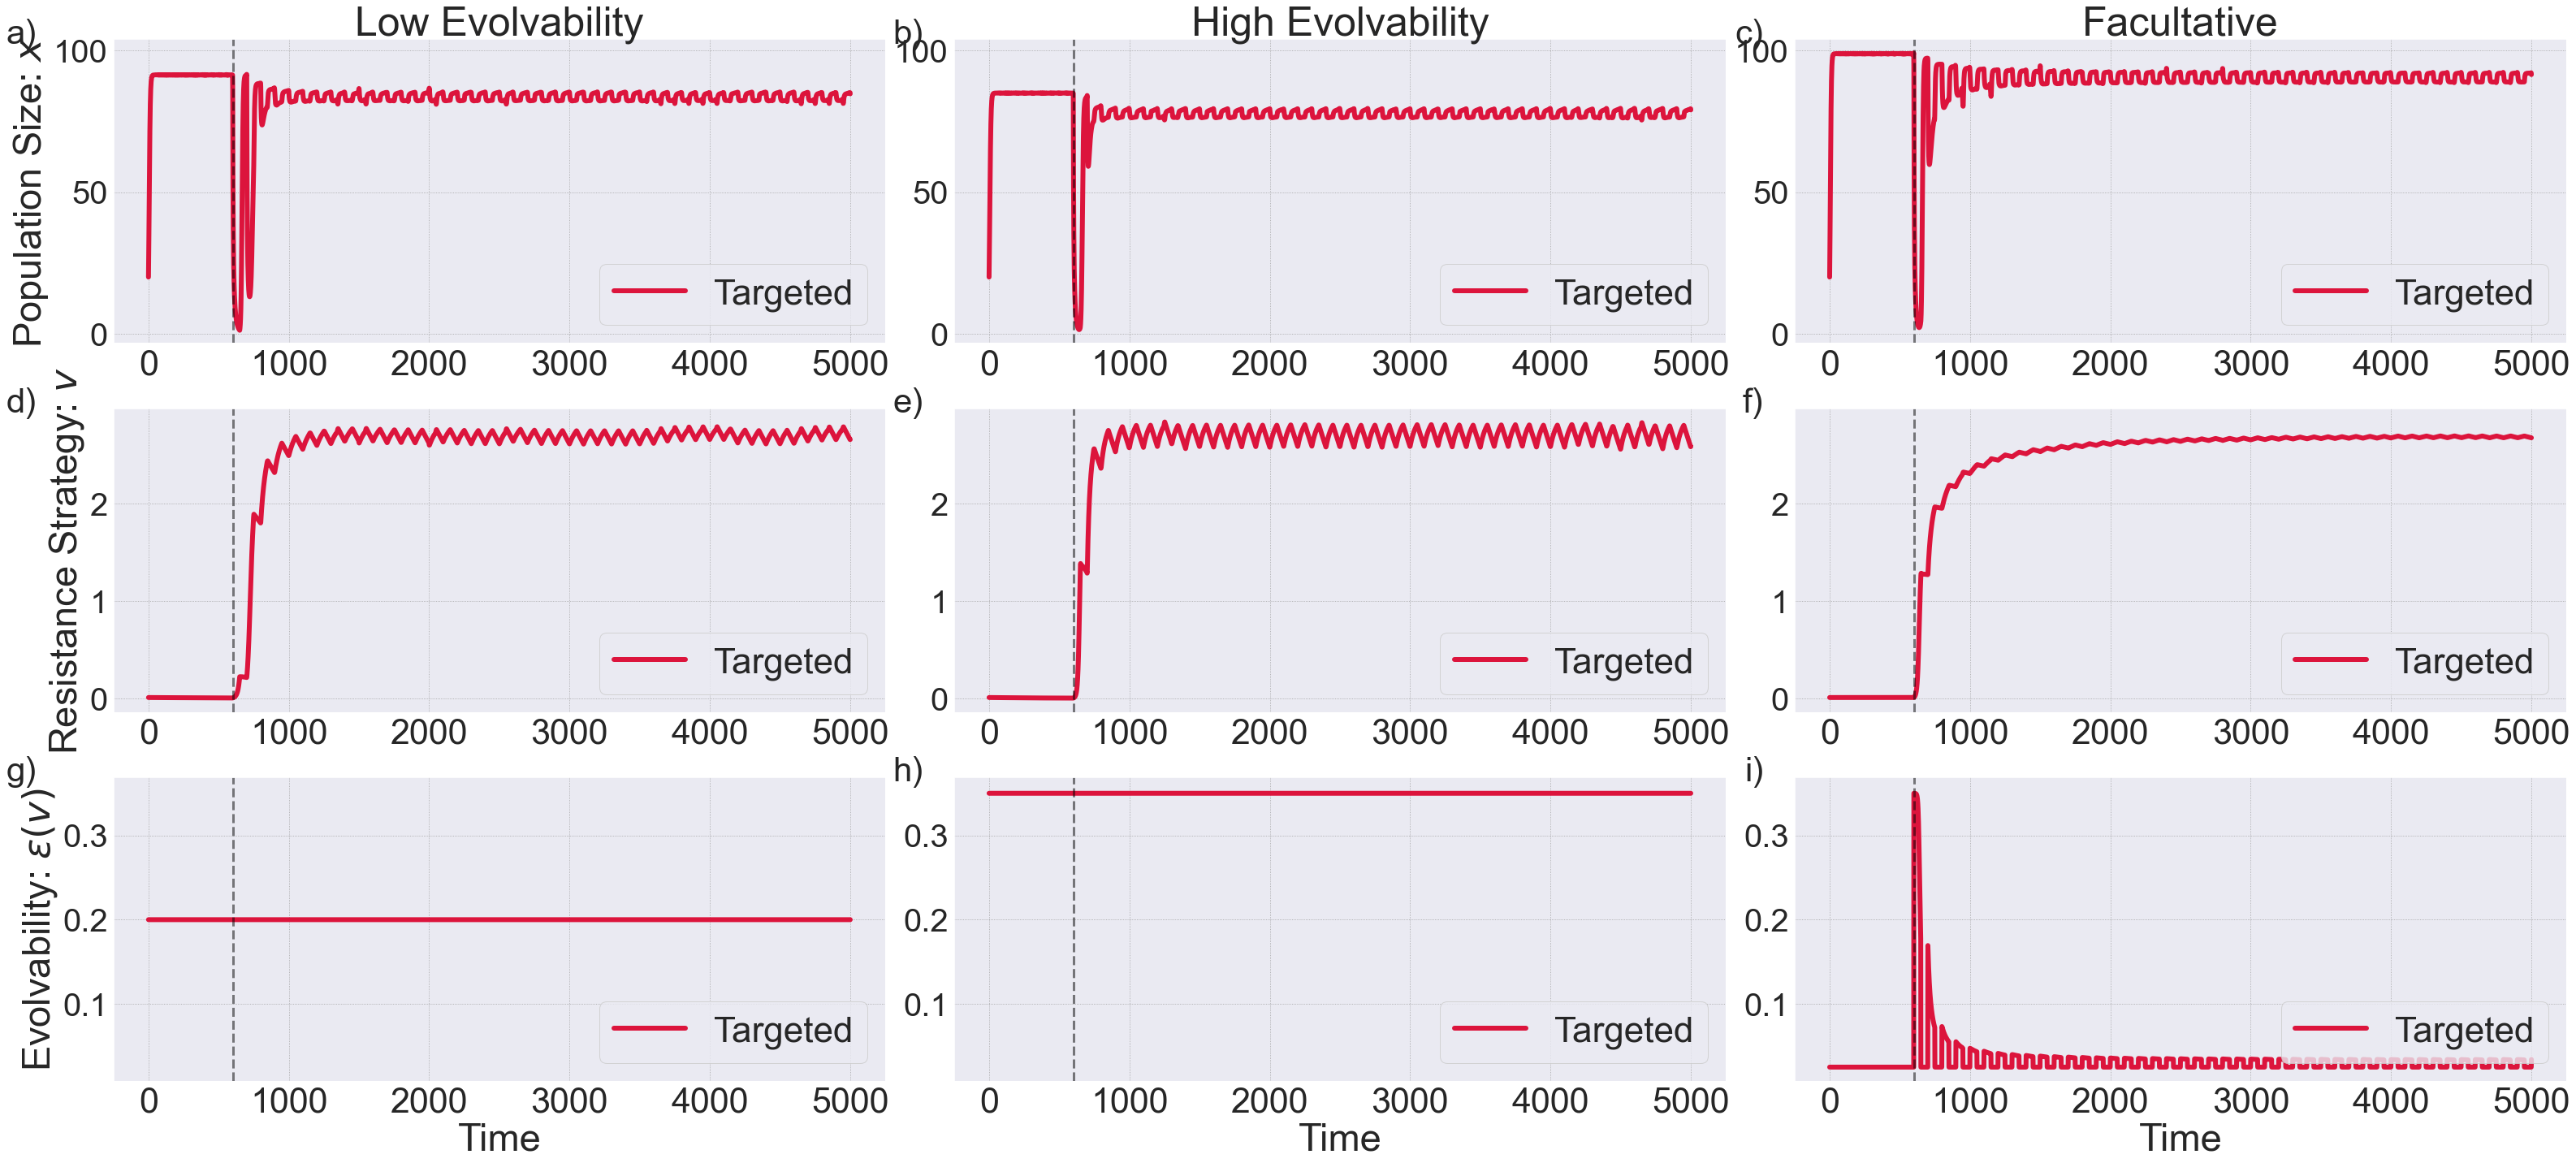

In [11]:
linewidth = 6
label_font = 42        # font for subplot labels (a), (b), etc.
font_title = 50        # font for subplot titles
font_axis = 47        # font for axis labels
font_legend = 44       # font for legend
font_ticks_y = 40      # font for y-axis tick labels
font_ticks_x = 43      # font for x-axis tick labels


panel_labels = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)', 'g)', 'h)', 'i)']
label_positions = [(-0.10, 1.07),  # (a) top-left
                   (-0.04, 1.07),  # (b) top-mid
                   (-0.04, 1.07),  # (c) top-right
                   (-0.10, 1.07),  # (d) mid-left
                   (-0.04, 1.07),  # (e) mid-mid
                   (-0.04, 1.07),  # (f) mid-right
                   (-0.10, 1.07),  # (g) bottom-left
                   (-0.04, 1.07),  # (h) bottom-mid
                    (-0.04, 1.07)]  # (h) bottom-right

fig, ax = plt.subplots(3, 3, figsize=(44, 20), sharex=True)

models = [
    ("Low Evolvability", low_evo_intermittent_targeted),
    ("High Evolvability", high_evo_intermittent_targeted),
    ("Facultative", facultative_intermittent_targeted),
]

# Row 0: Population
for j, (label, model) in enumerate(models):
    ax[0, j].plot(model.t, model.y[0], color=targeted_color, linewidth=linewidth, label="Targeted")
    ax[0, j].set_title(f"{label}", fontsize = font_title)
    ax[0, j].legend(loc="lower right")
    
# Row 1: Strategy
for j, (label, model) in enumerate(models):
    ax[1, j].plot(model.t, model.y[1], color=targeted_color, linewidth=linewidth, label="Targeted")
    ax[1, j].legend(loc="lower right")

# Row 2: Evolvability
for j, (label, model) in enumerate(models):
    ax[2, j].plot(model.t, model.evo, color=targeted_color, linewidth=linewidth, label="Targeted")
    ax[2, j].set_xlabel("Time", fontsize = font_axis)
    ax[2, j].legend(loc="lower right")

match_ylim_by_row(ax)
repeat_legend(ax)

# Y-axis labels
ax[0, 0].set_ylabel("Population Size: $x$", fontsize = font_axis)
ax[1, 0].set_ylabel("Resistance Strategy: $v$", fontsize = font_axis)
ax[2, 0].set_ylabel("Evolvability: $\epsilon(v)$", fontsize = font_axis)


# Final polish
for i, axes in enumerate(ax.flat):
    axes.axvline(x=high_evo_constant_model_chemo.therapy_start_time, color='black',
                 linestyle='--', linewidth=3, alpha=0.5)
    axes.tick_params(axis='x', labelsize=font_ticks_x)
    axes.tick_params(axis='y', labelsize=font_ticks_y)

    axes.legend(fontsize=font_legend, loc = "lower right")

    x_pos, y_pos = label_positions[i]
    axes.text(x_pos, y_pos, panel_labels[i], transform=axes.transAxes,
              fontsize=label_font, va='top', ha='right')
    
plt.tight_layout()
plt.show()

# print(np.min(high_evo_intermittent_targeted.y[0]), np.min(low_evo_intermittent_targeted.y[0]), np.min(facultative_intermittent_targeted.y[0]))
# print(high_evo_intermittent_targeted.y[0][2000:2100])
# print(low_evo_intermittent_targeted.y[0][2000:2100])
# print(facultative_intermittent_targeted.y[0][2000:2100])


## Double Bind

### Double bind with Short cycle_duration

In [12]:
init = [20, 0.01, 0.01]
t_max = 5000

# Facultative
double_bind_facultative = DoubleBindModel(
    init=init,
    t_max=t_max,
    growth_rate=growth_rate_fixed,
    carrying_capacity_std=maximum_carrying_capacity_std,
    efficacy_1=efficacy_chemo,
    efficacy_2=efficacy_targeted,
    efficacy_std_1=efficacy_chemo_std,
    efficacy_std_2=efficacy_targeted_std,
    evolvability_scaling_factor_1=evolvability_scaling_factor_chemo,
    evolvability_scaling_factor_2=evolvability_scaling_factor_targeted,
    evolvability_value=baseline_heterogeneity,
    facultative_evolvability=True,
    cycle_duration = cycle,
    covariance=cov
)


# Low evolvability
double_bind_low = DoubleBindModel(
    init=init,
    t_max=t_max,
    growth_rate=growth_rate_fixed,
    carrying_capacity_std=maximum_carrying_capacity_std,
    efficacy_1=efficacy_chemo,
    efficacy_2=efficacy_targeted,
    efficacy_std_1=efficacy_chemo_std,
    efficacy_std_2=efficacy_targeted_std,
    evolvability_value=LOW_EVOLVABILITY,
    facultative_evolvability=False,
    evolvability_scaling_factor_1=evolvability_scaling_factor_chemo,
    evolvability_scaling_factor_2=evolvability_scaling_factor_targeted,
    covariance=cov,
    cycle_duration = cycle
)



# High evolvability
double_bind_high = DoubleBindModel(
    init=init,
    t_max=t_max,
    growth_rate=growth_rate_fixed,
    carrying_capacity_std=maximum_carrying_capacity_std,
    efficacy_1=efficacy_chemo,
    efficacy_2=efficacy_targeted,
    efficacy_std_1=efficacy_chemo_std,
    efficacy_std_2=efficacy_targeted_std,
    evolvability_value=HIGH_EVOLVABILITY,
    facultative_evolvability=False,
    evolvability_scaling_factor_1=evolvability_scaling_factor_chemo,
    evolvability_scaling_factor_2=evolvability_scaling_factor_targeted,
    covariance=cov,
    cycle_duration = cycle
)



double_bind_facultative_switched = deepcopy(double_bind_facultative)
double_bind_low_switched = deepcopy(double_bind_low)
double_bind_high_switched = deepcopy(double_bind_high)

for model in [double_bind_facultative, double_bind_low, double_bind_high]:
    model.get_evolvability_scaling_factor(HIGH_EVOLVABILITY)
    #print(model.evolvability_scaling_factor_1, model.evolvability_scaling_factor_2)
    model.run()
    model.apply_extinction()

for model in [double_bind_facultative_switched, double_bind_low_switched, double_bind_high_switched]:
    model.switch_therapy_order()
    model.get_evolvability_scaling_factor(HIGH_EVOLVABILITY)
    model.run()
    model.apply_extinction()


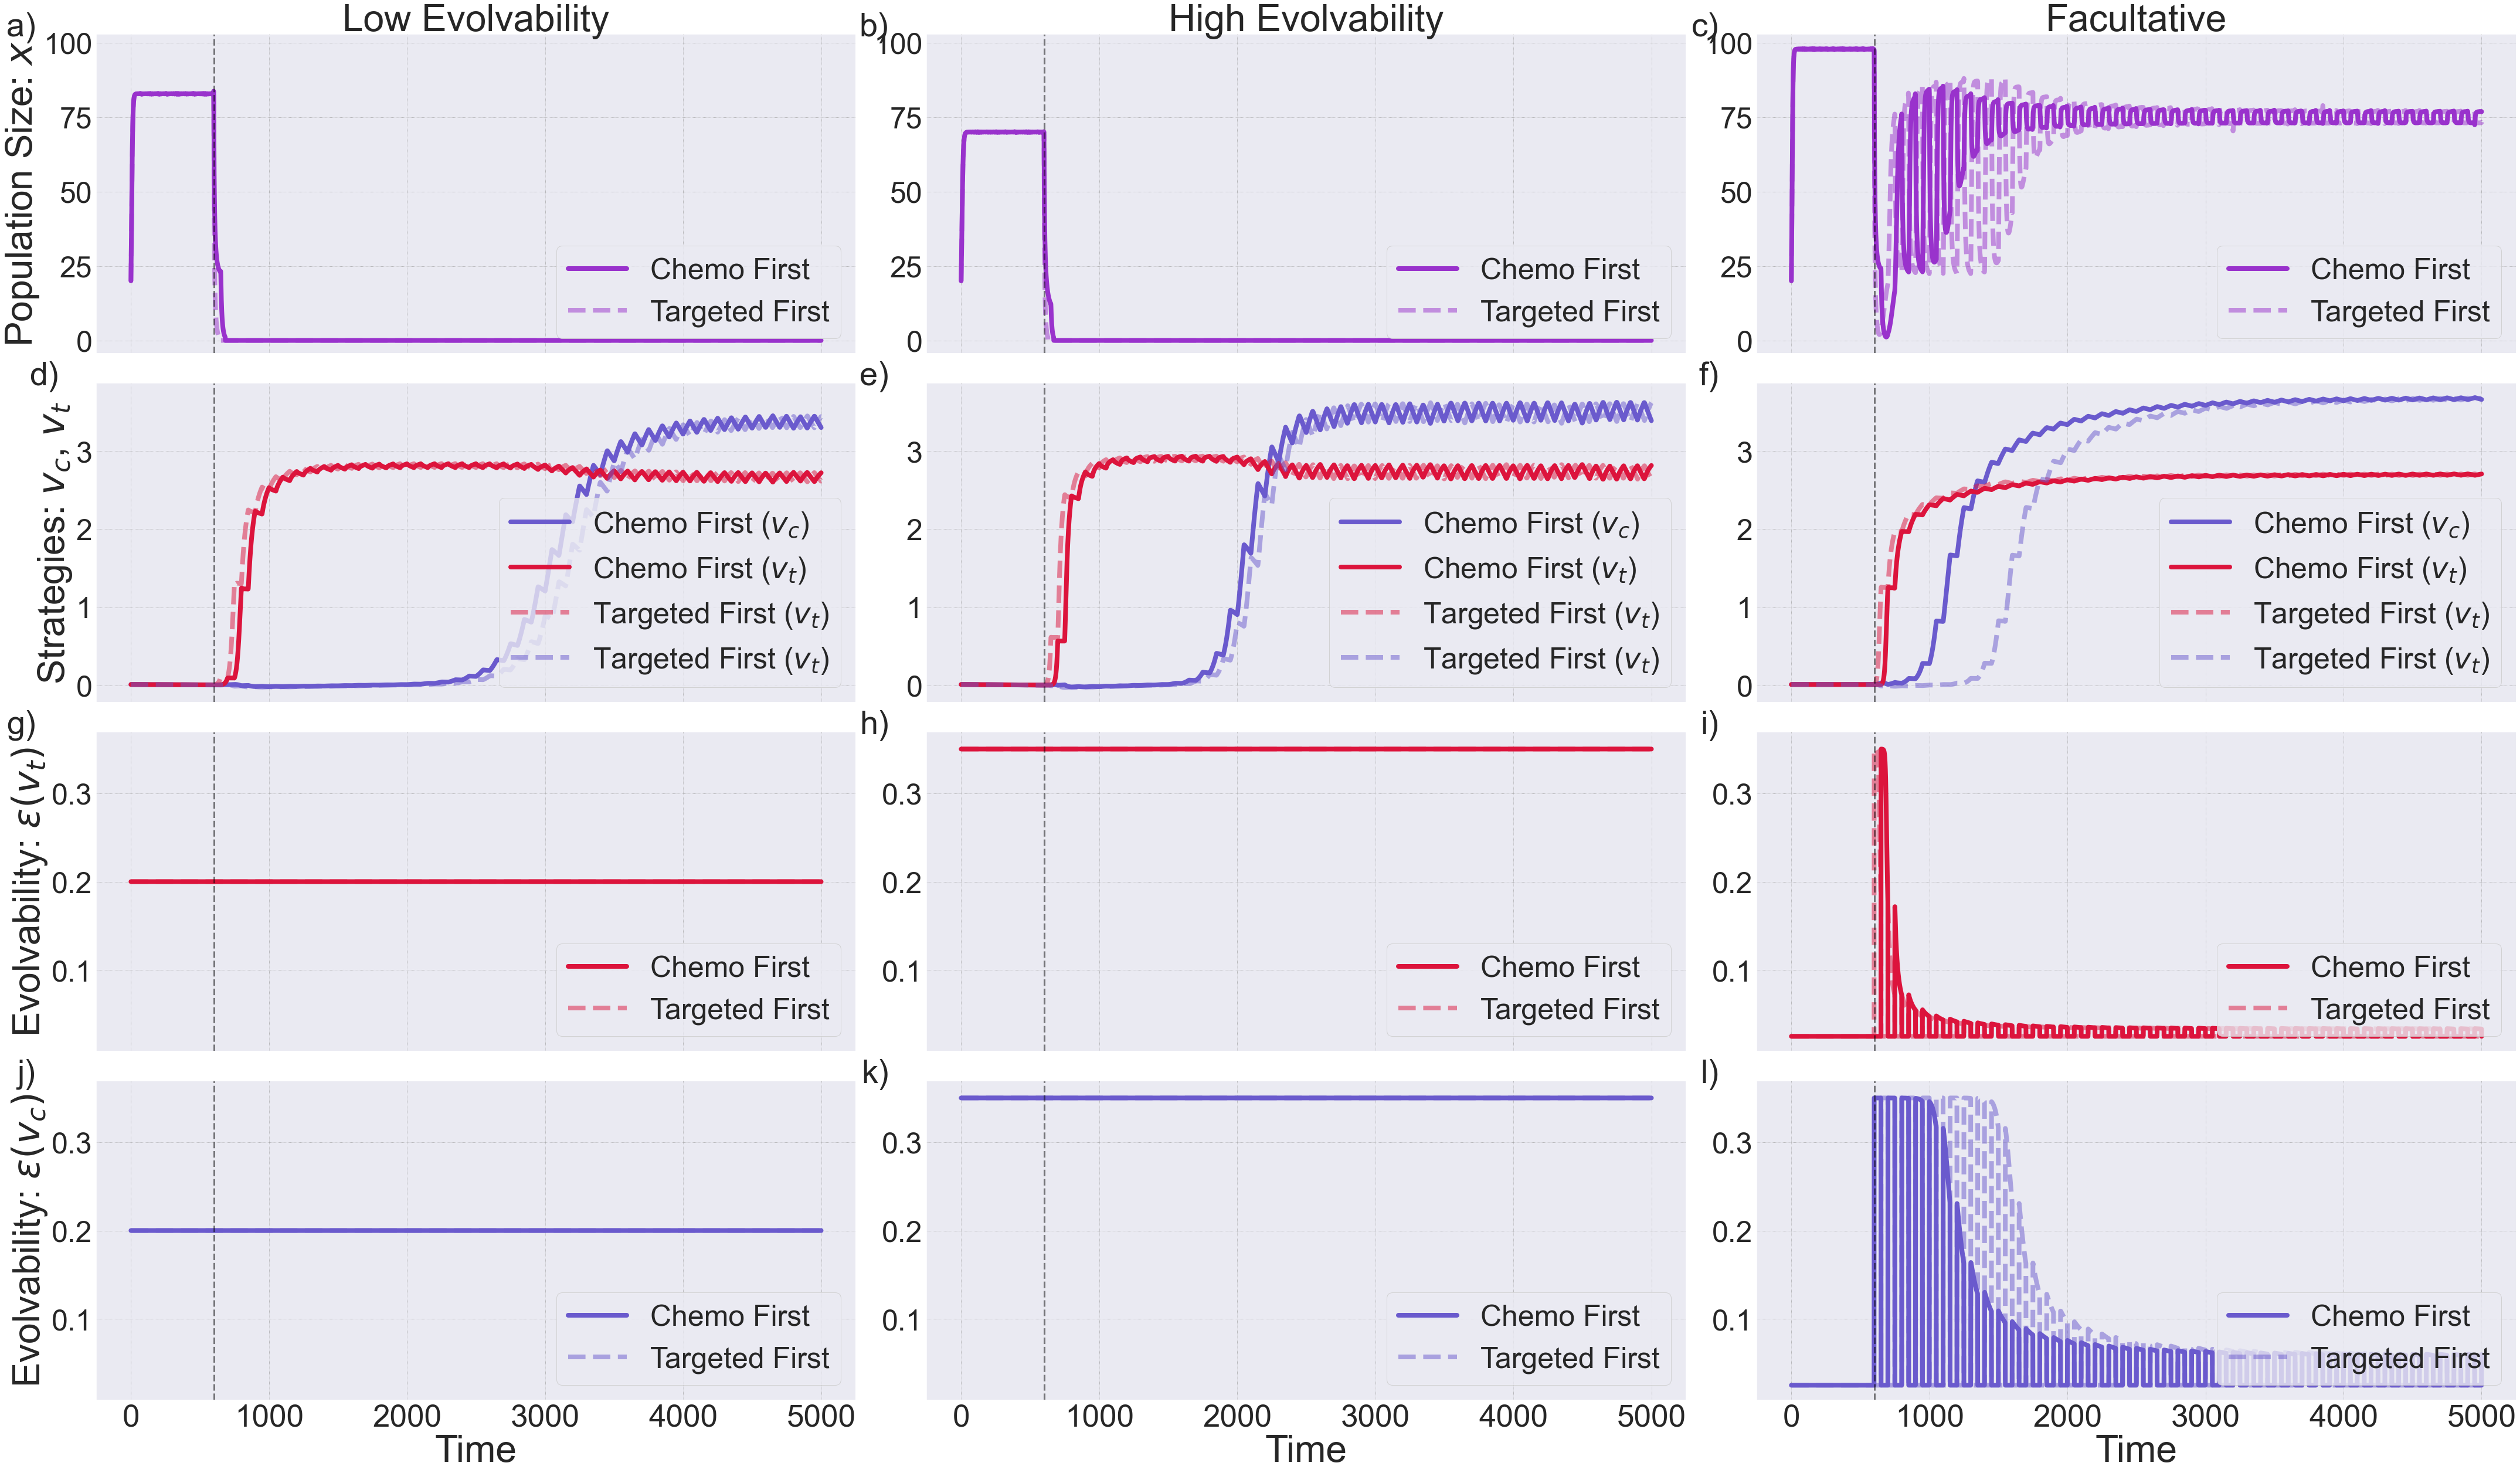

In [13]:
linewidth = 8
label_font = 56        # font for subplot labels (a), (b), etc.
font_title = 65        # font for subplot titles
font_axis = 64       # font for axis labels
font_legend = 50       # font for legend
font_ticks_y = 50      # font for y-axis tick labels
font_ticks_x = 53      # font for x-axis tick labels



panel_labels = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)', 'g)', 'h)', 'i)', 'j)', 'k)', 'l)']
label_positions = [(-0.08, 1.07),  # (a) top-first
                   (-0.05, 1.07),  # (b) top-second
                   (-0.05, 1.07),  # (c) top-third
                   (-0.05, 1.07),  # (d) top-fourth
                   (-0.05, 1.07),  # (e) mid-first
                   (-0.05, 1.07),  # (f) mid-second
                   (-0.08, 1.07),  # (g) mid-third
                   (-0.05, 1.07),  # (h) mid-fourth
                   (-0.05, 1.07),  # (i) bottom-first
                   (-0.08, 1.07),  # (j) bottom-second
                    (-0.05, 1.07),  # (k) bottom-third
                    (-0.05, 1.07)]  # (l) bottom-fourth

fig, ax = plt.subplots(4, 3, figsize=(60, 35), sharex=True)



models = [
    ("Low Evolvability", double_bind_low, double_bind_low_switched),
    ("High Evolvability", double_bind_high, double_bind_high_switched),
    ("Facultative", double_bind_facultative, double_bind_facultative_switched)]

# --- Row 0: Population ---
for j, (label, model, model_switched) in enumerate(models):
    ax[0, j].plot(model.t, model.y[0], color=double_bind_color, linewidth=linewidth, label="Chemo First")
    ax[0, j].plot(model_switched.t, model_switched.y[0], color=double_bind_color, linestyle="--", linewidth=linewidth, alpha=0.5, label="Targeted First")
    ax[0, j].set_title(f"{label}", fontsize = font_axis)
    ax[0, j].legend(loc="lower right")

# --- Row 1: Strategies (v1, v2) ----
for j, (label, model, model_switched) in enumerate(models):
    ax[1, j].plot(model.t, model.y[1], color=chemo_color, linewidth=linewidth, label="Chemo First ($v_c$)")
    ax[1, j].plot(model.t, model.y[2], color=targeted_color, linewidth=linewidth, label="Chemo First ($v_t$)")
    ax[1, j].plot(model_switched.t, model_switched.y[1], color=targeted_color, linestyle="--", linewidth=linewidth, alpha=0.5, label = "Targeted First ($v_t$)" )
    ax[1, j].plot(model_switched.t, model_switched.y[2], color=chemo_color, linestyle="--", linewidth=linewidth, alpha=0.5, label = "Targeted First ($v_t$)")
    #ax[1, j].set_title(f"{label} )
    ax[1, j].legend(loc="lower right")

# --- Row 2: Evolvability (Targeted) ---
for j, (label, model, model_switched) in enumerate(models):
    ax[2, j].plot(model.t, model.evo_2, color=targeted_color, linewidth=linewidth, label="Chemo First")
    ax[2, j].plot(model_switched.t, model_switched.evo_1, color=targeted_color, linestyle="--", linewidth=linewidth, alpha=0.5, label="Targeted First")
    #ax[2, j].set_title(f"{label} - Evolvability (Targeted): r'$\epsilon(v_t)$'", fontsize = font_axis)
    ax[2, j].legend(loc="lower right")

# --- Row 3: Evolvability (Chemo) ---
for j, (label, model, model_switched) in enumerate(models):
    ax[3, j].plot(model.t, model.evo_1, color=chemo_color, linewidth=linewidth, label="Chemo First")
    ax[3, j].plot(model_switched.t, model_switched.evo_2, color=chemo_color, linestyle="--", linewidth=linewidth, alpha=0.5, label="Targeted First")
    #ax[3, j].set_title(f"{label} - Evolvability (Chemo): '$\epsilon(v_c)$'", fontsize = font_axis)
    ax[3, j].set_xlabel("Time", fontsize = font_axis)
    ax[3, j].legend(loc="lower right")

# --- Y labels (left column only) ---
ax[0, 0].set_ylabel("Population Size: $x$", fontsize=font_axis)
ax[1, 0].set_ylabel(r"Strategies: $v_c$, $v_t$", fontsize=font_axis)
ax[2, 0].set_ylabel(r"Evolvability: $\epsilon(v_t)$", fontsize=font_axis)
ax[3, 0].set_ylabel(r"Evolvability: $\epsilon(v_c)$", fontsize=font_axis)


# --- Match y-limits row-wise ---
match_ylim_by_row(ax)

# Final polish
for i, axes in enumerate(ax.flat):
    axes.axvline(x=high_evo_constant_model_chemo.therapy_start_time, color='black',
                 linestyle='--', linewidth=3, alpha=0.5)
    axes.tick_params(axis='x', labelsize=font_ticks_x)
    axes.tick_params(axis='y', labelsize=font_ticks_y)

    axes.legend(fontsize=font_legend, loc = "lower right")

    x_pos, y_pos = label_positions[i]
    axes.text(x_pos, y_pos, panel_labels[i], transform=axes.transAxes,
              fontsize=label_font, va='top', ha='right')
    
plt.tight_layout()
plt.show()


#print(double_bind_high.y[0][500], double_bind_low.y[0][500], double_bind_facultative.y[0][500])


### Double Bind with Longer cycle duration

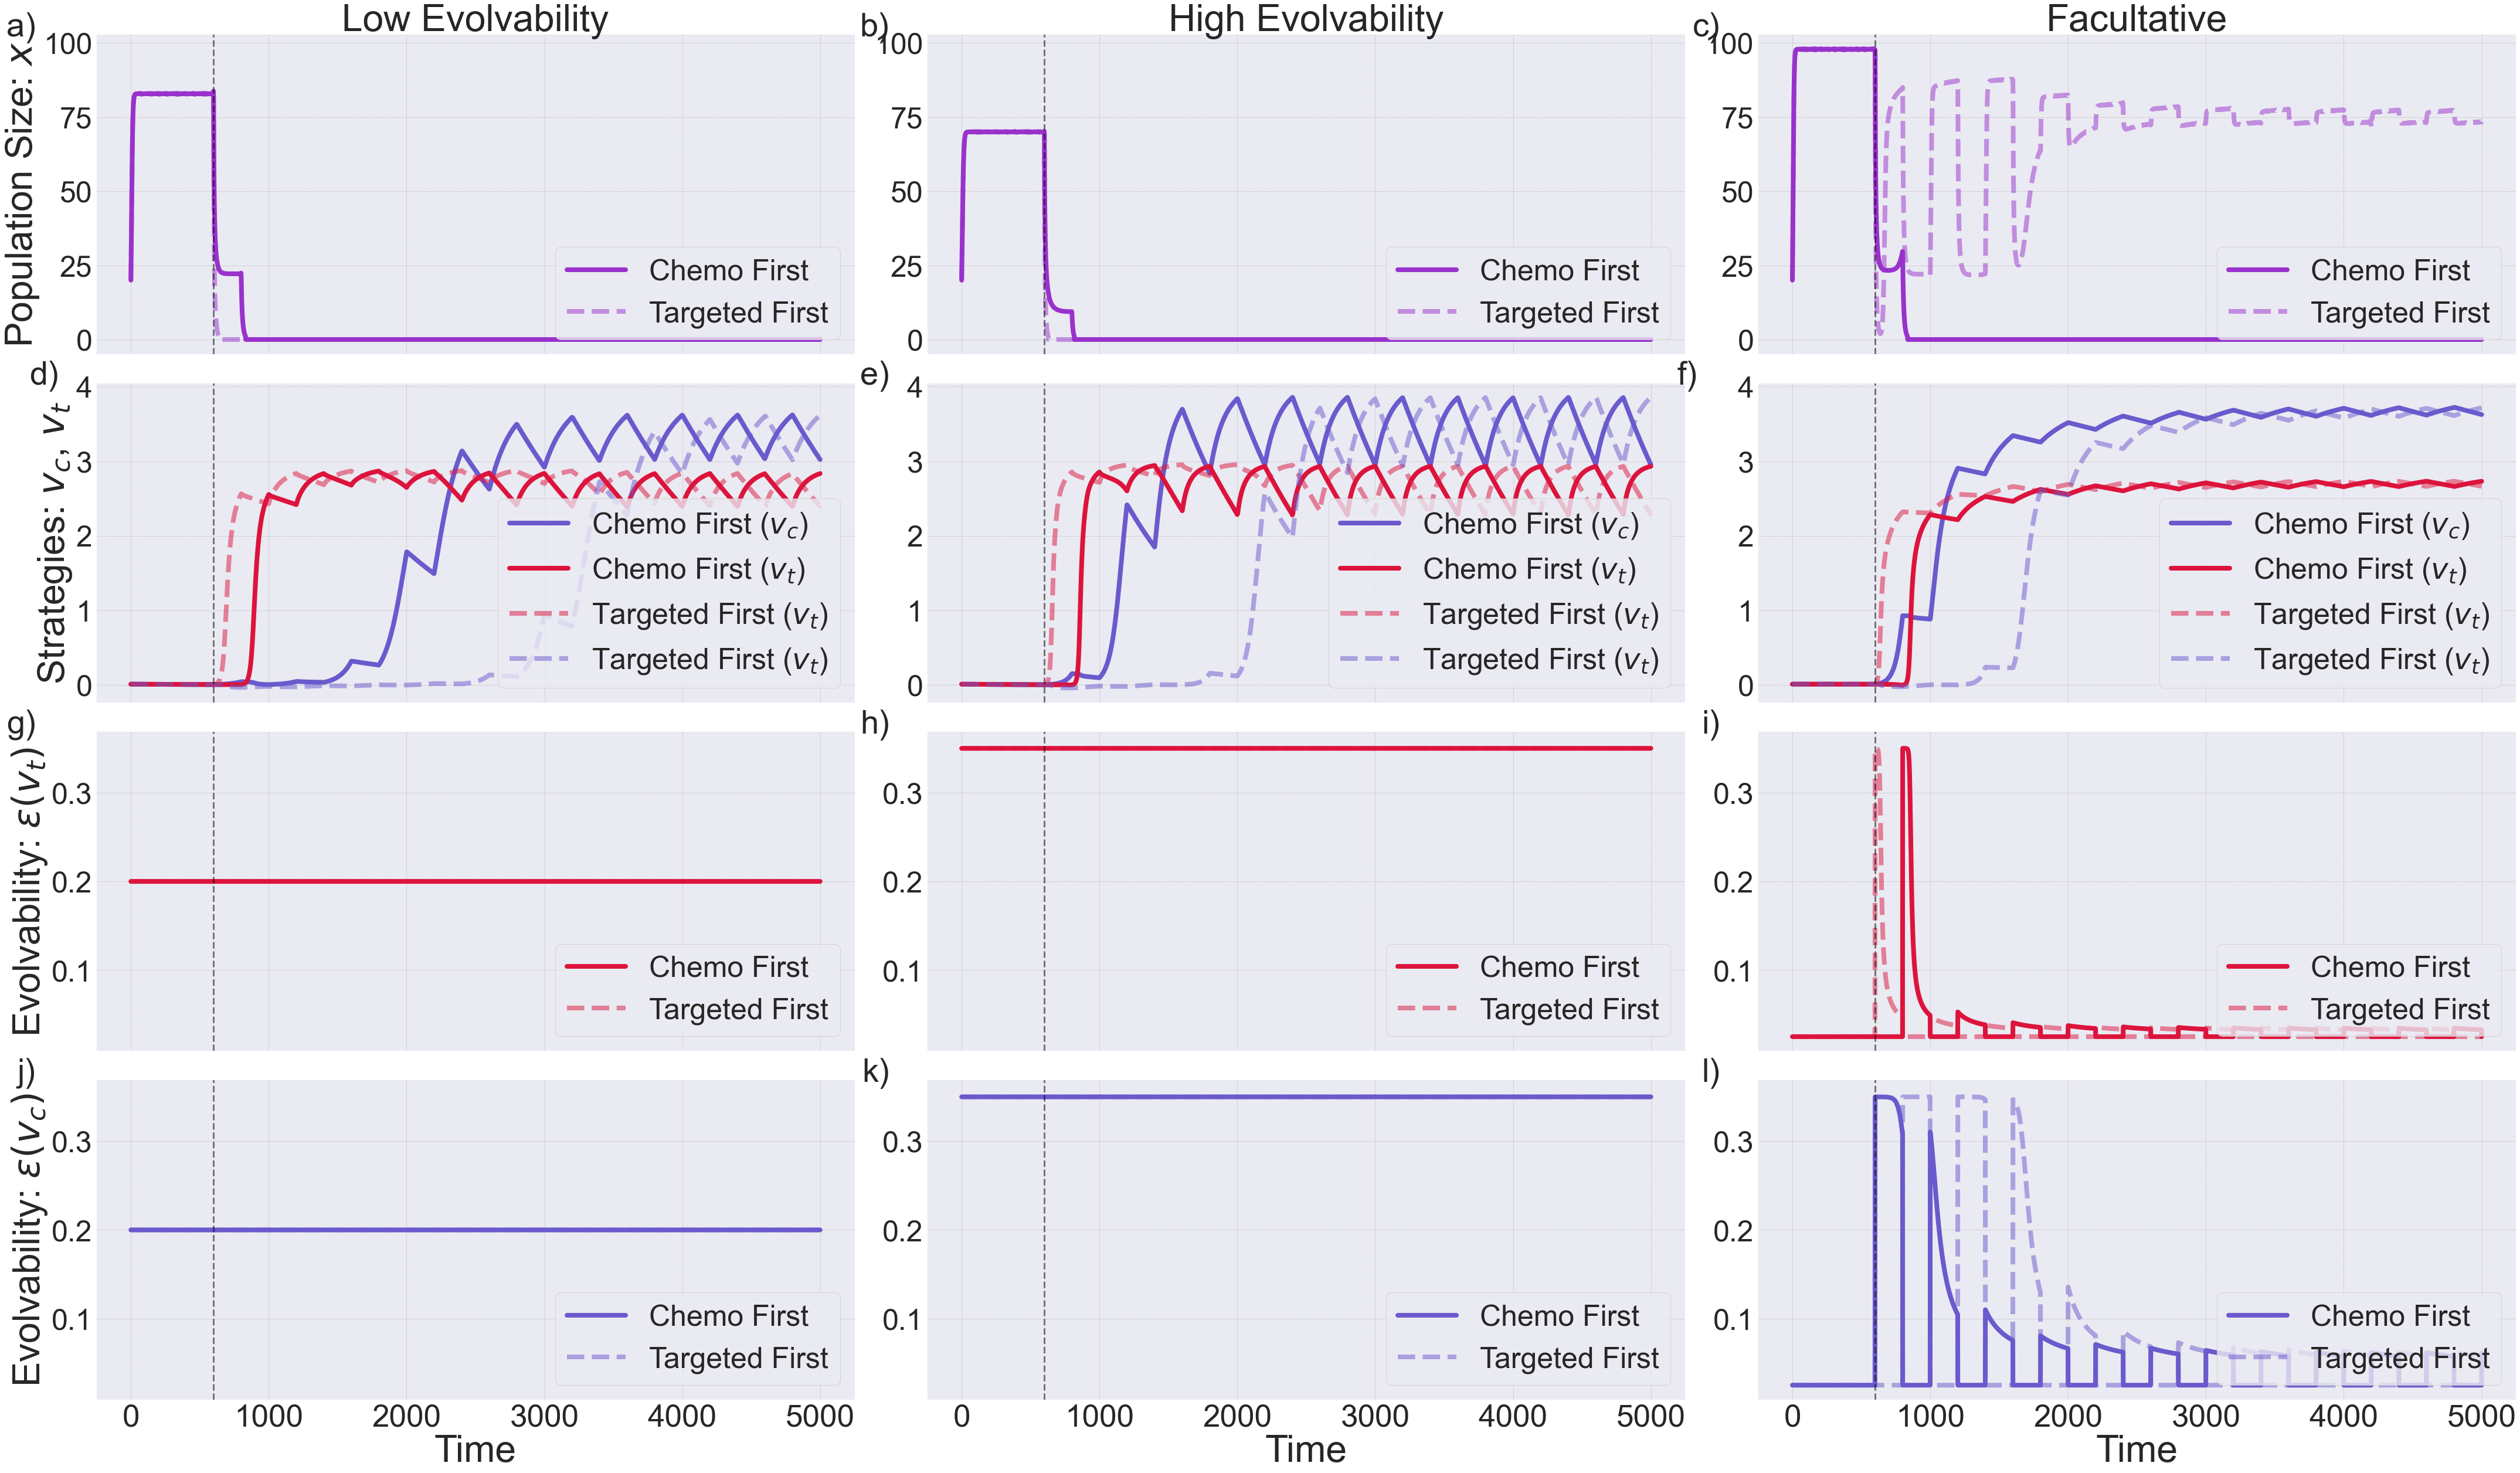

In [14]:
cycle_long = 200

for model in [double_bind_facultative, double_bind_low, double_bind_high] + [double_bind_facultative_switched, double_bind_low_switched, double_bind_high_switched]:
    model.set_params(cycle_duration = cycle_long)
    model.get_evolvability_scaling_factor(HIGH_EVOLVABILITY)
    #print(model.evolvability_scaling_factor_1, model.evolvability_scaling_factor_2)
    model.run()
    model.apply_extinction()

linewidth = 8
label_font = 56        # font for subplot labels (a), (b), etc.
font_title = 65        # font for subplot titles
font_axis = 64       # font for axis labels
font_legend = 50       # font for legend
font_ticks_y = 50      # font for y-axis tick labels
font_ticks_x = 53      # font for x-axis tick labels


panel_labels = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)', 'g)', 'h)', 'i)', 'j)', 'k)', 'l)']
label_positions = [(-0.08, 1.07),  # (a) top-first
                   (-0.05, 1.07),  # (b) top-second
                   (-0.05, 1.07),  # (c) top-third
                   (-0.05, 1.07),  # (d) top-fourth
                   (-0.05, 1.07),  # (e) mid-first
                   (-0.08, 1.07),  # (f) mid-second
                   (-0.08, 1.07),  # (g) mid-third
                   (-0.05, 1.07),  # (h) mid-fourth
                   (-0.05, 1.07),  # (i) bottom-first
                   (-0.08, 1.07),  # (j) bottom-second
                    (-0.05, 1.07),  # (k) bottom-third
                    (-0.05, 1.07)]  # (l) bottom-fourth

fig, ax = plt.subplots(4, 3, figsize=(60, 35), sharex=True)



models = [
    ("Low Evolvability", double_bind_low, double_bind_low_switched),
    ("High Evolvability", double_bind_high, double_bind_high_switched),
    ("Facultative", double_bind_facultative, double_bind_facultative_switched)]

# --- Row 0: Population ---
for j, (label, model, model_switched) in enumerate(models):
    ax[0, j].plot(model.t, model.y[0], color=double_bind_color, linewidth=linewidth, label="Chemo First")
    ax[0, j].plot(model_switched.t, model_switched.y[0], color=double_bind_color, linestyle="--", linewidth=linewidth, alpha=0.5, label="Targeted First")
    ax[0, j].set_title(f"{label}", fontsize = font_axis)
    ax[0, j].legend(loc="lower right")

# --- Row 1: Strategies (v1, v2) ----
for j, (label, model, model_switched) in enumerate(models):
    ax[1, j].plot(model.t, model.y[1], color=chemo_color, linewidth=linewidth, label="Chemo First ($v_c$)")
    ax[1, j].plot(model.t, model.y[2], color=targeted_color, linewidth=linewidth, label="Chemo First ($v_t$)")
    ax[1, j].plot(model_switched.t, model_switched.y[1], color=targeted_color, linestyle="--", linewidth=linewidth, alpha=0.5, label = "Targeted First ($v_t$)" )
    ax[1, j].plot(model_switched.t, model_switched.y[2], color=chemo_color, linestyle="--", linewidth=linewidth, alpha=0.5, label = "Targeted First ($v_t$)")
    ax[1, j].legend(loc="lower right")

# --- Row 2: Evolvability (Targeted) ---
for j, (label, model, model_switched) in enumerate(models):
    ax[2, j].plot(model.t, model.evo_2, color=targeted_color, linewidth=linewidth, label="Chemo First")
    ax[2, j].plot(model_switched.t, model_switched.evo_1, color=targeted_color, linestyle="--", linewidth=linewidth, alpha=0.5, label="Targeted First")
    ax[2, j].legend(loc="lower right")

# --- Row 3: Evolvability (Chemo) ---
for j, (label, model, model_switched) in enumerate(models):
    ax[3, j].plot(model.t, model.evo_1, color=chemo_color, linewidth=linewidth, label="Chemo First")
    ax[3, j].plot(model_switched.t, model_switched.evo_2, color=chemo_color, linestyle="--", linewidth=linewidth, alpha=0.5, label="Targeted First")
    ax[3, j].set_xlabel("Time", fontsize = font_axis)
    ax[3, j].legend(loc="lower right")

# --- Y labels (left column only) ---
ax[0, 0].set_ylabel("Population Size: $x$", fontsize=font_axis)
ax[1, 0].set_ylabel(r"Strategies: $v_c$, $v_t$", fontsize=font_axis)
ax[2, 0].set_ylabel(r"Evolvability: $\epsilon(v_t)$", fontsize=font_axis)
ax[3, 0].set_ylabel(r"Evolvability: $\epsilon(v_c)$", fontsize=font_axis)


# --- Match y-limits row-wise ---
match_ylim_by_row(ax)

# Final polish
for i, axes in enumerate(ax.flat):
    axes.axvline(x=high_evo_constant_model_chemo.therapy_start_time, color='black',
                 linestyle='--', linewidth=3, alpha=0.5)
    axes.tick_params(axis='x', labelsize=font_ticks_x)
    axes.tick_params(axis='y', labelsize=font_ticks_y)

    axes.legend(fontsize=font_legend, loc = "lower right")

    x_pos, y_pos = label_positions[i]
    axes.text(x_pos, y_pos, panel_labels[i], transform=axes.transAxes,
              fontsize=label_font, va='top', ha='right')
    
plt.tight_layout()
plt.show()



# Combination Therapy

### Full Drug Efficacy

In [15]:
init = [20, 0.01, 0.01]
t_max = 5000

# Facultative
combination_facultative = CombinationModel(
    init=init,
    t_max=t_max,
    growth_rate=growth_rate_fixed,
    carrying_capacity_std=maximum_carrying_capacity_std,
    efficacy_1=efficacy_chemo,
    efficacy_2=efficacy_targeted,
    efficacy_std_1=efficacy_chemo_std,
    efficacy_std_2=efficacy_targeted_std,
    evolvability_scaling_factor_1=evolvability_scaling_factor_chemo,
    evolvability_scaling_factor_2=evolvability_scaling_factor_targeted,
    evolvability_value=baseline_heterogeneity,
    facultative_evolvability=True,
    covariance=cov
)


# Low evolvability
combination_low = CombinationModel(
    init=init,
    t_max=t_max,
    growth_rate=growth_rate_fixed,
    carrying_capacity_std=maximum_carrying_capacity_std,
    efficacy_1=efficacy_chemo,
    efficacy_2=efficacy_targeted,
    efficacy_std_1=efficacy_chemo_std,
    efficacy_std_2=efficacy_targeted_std,
    evolvability_value=LOW_EVOLVABILITY,
    facultative_evolvability=False,
    evolvability_scaling_factor_1=evolvability_scaling_factor_chemo,
    evolvability_scaling_factor_2=evolvability_scaling_factor_targeted,
    covariance=cov
)



# High evolvability
combination_high = CombinationModel(
    init=init,
    t_max=t_max,
    growth_rate=growth_rate_fixed,
    carrying_capacity_std=maximum_carrying_capacity_std,
    efficacy_1=efficacy_chemo,
    efficacy_2=efficacy_targeted,
    efficacy_std_1=efficacy_chemo_std,
    efficacy_std_2=efficacy_targeted_std,
    evolvability_value=HIGH_EVOLVABILITY,
    facultative_evolvability=False,
    evolvability_scaling_factor_1=evolvability_scaling_factor_chemo,
    evolvability_scaling_factor_2=evolvability_scaling_factor_targeted,
    covariance=cov
)


for model in [combination_facultative, combination_low, combination_high]:
    model.get_evolvability_scaling_factor(HIGH_EVOLVABILITY)
    model.run()
    model.apply_extinction()



### Half Drug Efficacy

In [16]:
init = [20, 0.01, 0.01]
t_max = 5000

# Facultative
combination_facultative_half = CombinationModel(
    init=init,
    t_max=t_max,
    growth_rate=growth_rate_fixed,
    carrying_capacity_std=maximum_carrying_capacity_std,
    efficacy_1=efficacy_chemo / 2,
    efficacy_2=efficacy_targeted /2,
    efficacy_std_1=efficacy_chemo_std,
    efficacy_std_2=efficacy_targeted_std,
    evolvability_scaling_factor_1=evolvability_scaling_factor_chemo,
    evolvability_scaling_factor_2=evolvability_scaling_factor_targeted,
    evolvability_value=baseline_heterogeneity,
    facultative_evolvability=True,
    covariance=cov
)


# Low evolvability
combination_low_half = CombinationModel(
    init=init,
    t_max=t_max,
    growth_rate=growth_rate_fixed,
    carrying_capacity_std=maximum_carrying_capacity_std,
    efficacy_1=efficacy_chemo/2,
    efficacy_2=efficacy_targeted/2,
    efficacy_std_1=efficacy_chemo_std,
    efficacy_std_2=efficacy_targeted_std,
    evolvability_value=LOW_EVOLVABILITY,
    facultative_evolvability=False,
    evolvability_scaling_factor_1=evolvability_scaling_factor_chemo,
    evolvability_scaling_factor_2=evolvability_scaling_factor_targeted,
    covariance=cov
)



# High evolvability
combination_high_half = CombinationModel(
    init=init,
    t_max=t_max,
    growth_rate=growth_rate_fixed,
    carrying_capacity_std=maximum_carrying_capacity_std,
    efficacy_1=efficacy_chemo/2,
    efficacy_2=efficacy_targeted/2,
    efficacy_std_1=efficacy_chemo_std,
    efficacy_std_2=efficacy_targeted_std,
    evolvability_value=HIGH_EVOLVABILITY,
    facultative_evolvability=False,
    evolvability_scaling_factor_1=evolvability_scaling_factor_chemo,
    evolvability_scaling_factor_2=evolvability_scaling_factor_targeted,
    covariance=cov
)


for model in [combination_facultative_half, combination_low_half, combination_high_half]:
    model.get_evolvability_scaling_factor(HIGH_EVOLVABILITY)
    model.run()
    model.apply_extinction()



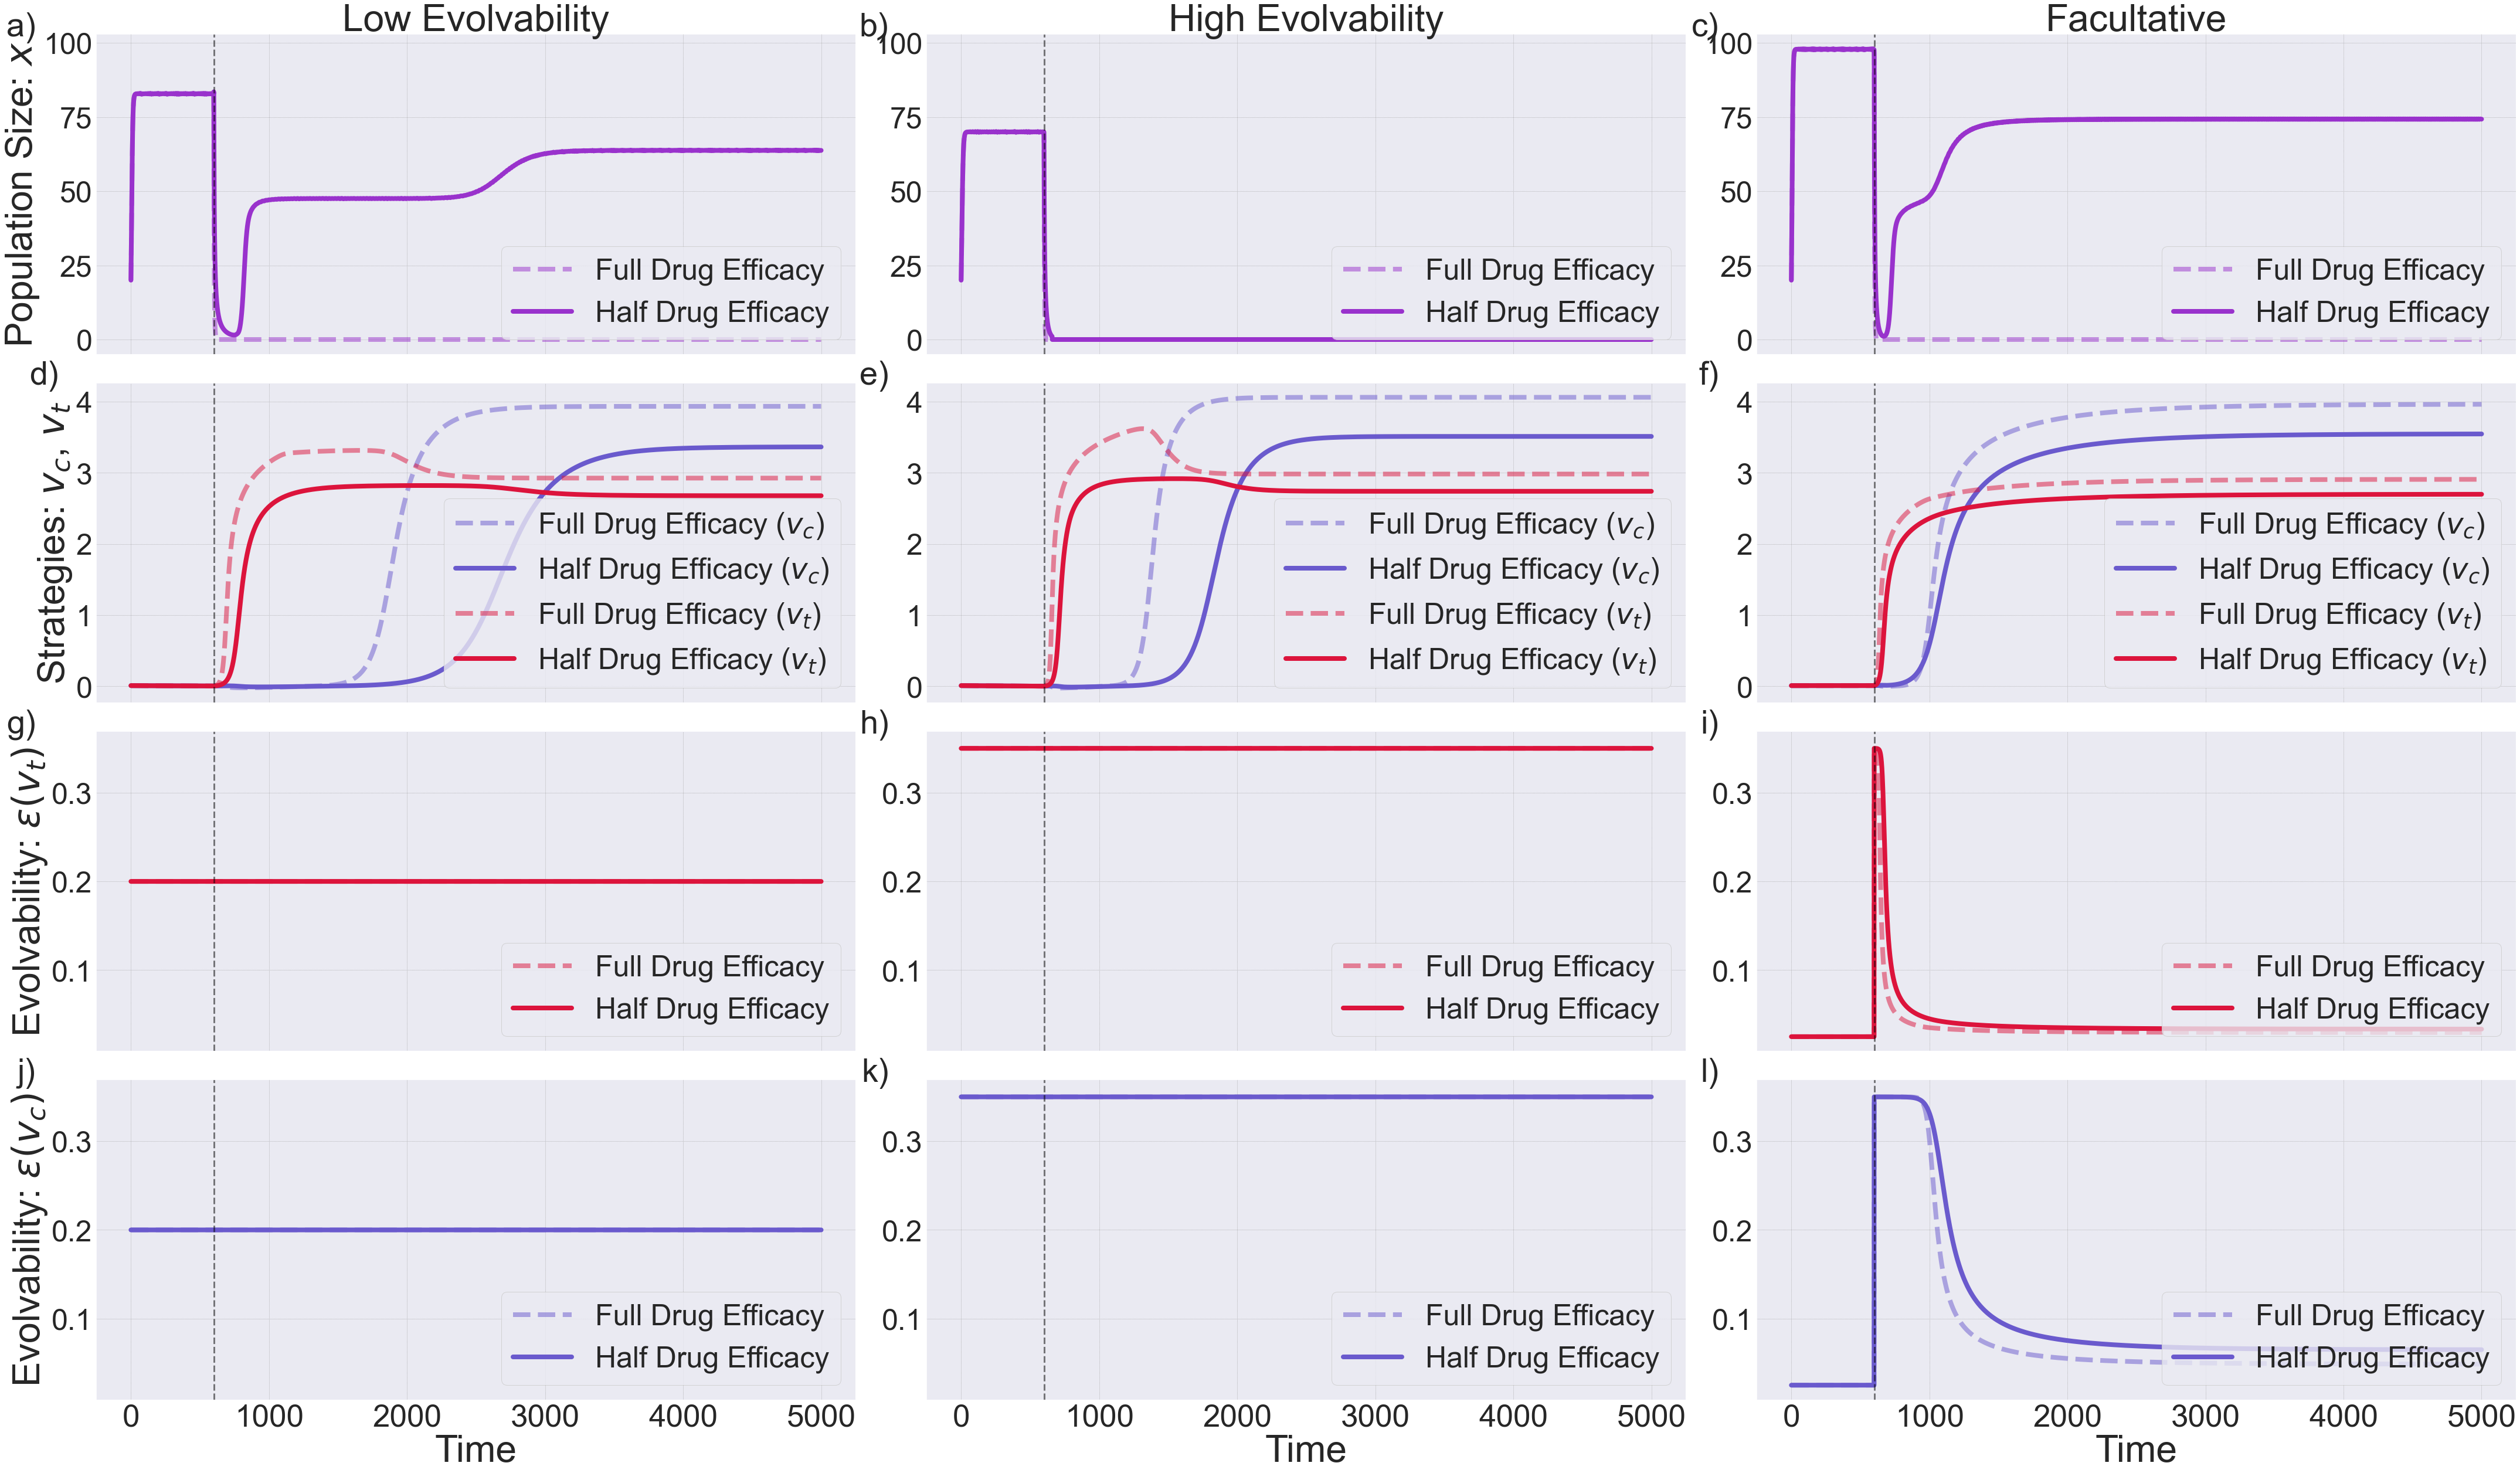

In [17]:
linewidth = 8
label_font = 56        # font for subplot labels (a), (b), etc.
font_title = 65        # font for subplot titles
font_axis = 64       # font for axis labels
font_legend = 50       # font for legend
font_ticks_y = 50      # font for y-axis tick labels
font_ticks_x = 53      # font for x-axis tick labels


panel_labels = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)', 'g)', 'h)', 'i)', 'j)', 'k)', 'l)']
label_positions = [(-0.08, 1.07),  # (a) top-first
                   (-0.05, 1.07),  # (b) top-second
                   (-0.05, 1.07),  # (c) top-third
                   (-0.05, 1.07),  # (d) top-fourth
                   (-0.05, 1.07),  # (e) mid-first
                   (-0.05, 1.07),  # (f) mid-second
                   (-0.08, 1.07),  # (g) mid-third
                   (-0.05, 1.07),  # (h) mid-fourth
                   (-0.05, 1.07),  # (i) bottom-first
                   (-0.08, 1.07),  # (j) bottom-second
                    (-0.05, 1.07),  # (k) bottom-third
                    (-0.05, 1.07)]  # (l) bottom-fourth

fig, ax = plt.subplots(4, 3, figsize=(60, 35), sharex=True)



models = [
    ("Low Evolvability", combination_low, combination_low_half),
    ("High Evolvability", combination_high, combination_high_half),
    ("Facultative", combination_facultative, combination_facultative_half)]

# --- Row 0: Population ---
for j, (label, model, model_half) in enumerate(models):
    ax[0, j].plot(model.t, model.y[0], color=double_bind_color, linewidth=linewidth, linestyle = '--', alpha=0.5, label="Full Drug Efficacy")
    ax[0, j].plot(model_half.t, model_half.y[0], color=double_bind_color, linewidth=linewidth, linestyle = '-', label="Half Drug Efficacy")
    ax[0, j].set_title(f"{label}", fontsize = font_axis)
    ax[0, j].legend(loc="lower right")

# --- Row 1: Strategies (v1, v2) ----
for j, (label, model, model_half) in enumerate(models):
    ax[1, j].plot(model.t, model.y[1], color=chemo_color, linewidth=linewidth, linestyle = '--', alpha=0.5, label="Full Drug Efficacy ($v_c$)")
    ax[1, j].plot(model_half.t, model_half.y[1], color=chemo_color, linewidth=linewidth, linestyle = '-', label="Half Drug Efficacy ($v_c$)")
    ax[1, j].plot(model.t, model.y[2], color=targeted_color, linewidth=linewidth, linestyle = '--', alpha=0.5, label="Full Drug Efficacy ($v_t$)")
    ax[1, j].plot(model_half.t, model_half.y[2], color=targeted_color, linewidth=linewidth, linestyle = '-', label="Half Drug Efficacy ($v_t$)")
    #ax[1, j].set_title(f"{label} )
    ax[1, j].legend(loc="lower right")

# --- Row 2: Evolvability (Targeted) ---
for j, (label, model, model_half) in enumerate(models):
    ax[2, j].plot(model.t, model.evo_2, color=targeted_color, linewidth=linewidth, linestyle = '--', alpha=0.5, label="Full Drug Efficacy")
    ax[2, j].plot(model_half.t, model_half.evo_2, color=targeted_color, linewidth=linewidth, linestyle = '-', label="Half Drug Efficacy")
    ax[2, j].legend(loc="lower right")

# --- Row 3: Evolvability (Chemo) ---
for j, (label, model, model_half) in enumerate(models):
    ax[3, j].plot(model.t, model.evo_1, color=chemo_color, linewidth=linewidth, linestyle = '--', alpha=0.5, label="Full Drug Efficacy")
    ax[3, j].plot(model_half.t, model_half.evo_1, color=chemo_color, linewidth=linewidth, linestyle = '-', label="Half Drug Efficacy")
    ax[3, j].set_xlabel("Time", fontsize = font_axis)
    ax[3, j].legend(loc="lower right")

# --- Y labels (left column only) ---
ax[0, 0].set_ylabel("Population Size: $x$", fontsize=font_axis)
ax[1, 0].set_ylabel(r"Strategies: $v_c$, $v_t$", fontsize=font_axis)
ax[2, 0].set_ylabel(r"Evolvability: $\epsilon(v_t)$", fontsize=font_axis)
ax[3, 0].set_ylabel(r"Evolvability: $\epsilon(v_c)$", fontsize=font_axis)


# --- Match y-limits row-wise ---
match_ylim_by_row(ax)

# Final polish
for i, axes in enumerate(ax.flat):
    axes.axvline(x=combination_facultative.therapy_start_time, color='black',
                 linestyle='--', linewidth=3, alpha=0.5)
    axes.tick_params(axis='x', labelsize=font_ticks_x)
    axes.tick_params(axis='y', labelsize=font_ticks_y)

    axes.legend(fontsize=font_legend, loc = "lower right")

    x_pos, y_pos = label_positions[i]
    axes.text(x_pos, y_pos, panel_labels[i], transform=axes.transAxes,
              fontsize=label_font, va='top', ha='right')
    
plt.tight_layout()
plt.show()


# print(double_bind_high.y[0][500])

# print(double_bind_low.y[0][500])

# print(double_bind_facultative.y[0][500])

